# 06 — Hane Pasiflik Riski: Modelleme, Doğrulama ve Açıklanabilirlik

## Bu notebook neyi çözüyor?

Notebook 05 her satırı bir `household_key × snapshot_day` gözlemi olan,
geleceği görmeden üretilmiş bir model paneli hazırladı. Bu notebookun amacı,
snapshot gününe kadar gözlenen davranıştan hareketle bir hanenin izleyen 56 günde
hiç geçerli alışveriş sepeti oluşturmayacağını tahmin etmektir.

**Pozitif sınıf:**

$$
\text{target\_inactive} =
\begin{cases}
1, & \text{izleyen 56 gündeki geçerli sepet sayısı } = 0 \\
0, & \text{izleyen 56 gündeki geçerli sepet sayısı } > 0
\end{cases}
$$

Bu hedef, sözleşmeli bir hizmetteki kesin **“churn”** değildir. Perakende bağlamında **izleyen dönemde alışveriş pasifliği** olarak yorumlanmalıdır.

### Temel modelleme ilkesi

Model seçimi ve değerlendirme kronolojik yapılır:

- Train snapshot'ları: `431, 487, 543`
- Validation snapshot'ı: `599`
- Test snapshot'ı: `655`

Aynı hane farklı snapshot'larda bulunabileceği için satır bazlı rastgele
train/test ayrımı veya random `KFold` kullanılmaz. Ham `predict_proba` değeri
otomatik olarak gerçek olasılık kabul edilmez. Customer 360 ve chatbot için
validation'da denetlenmiş son olasılık kullanılır: doğal model olasılığı ile
train out-of-fold skorlarından öğrenilen Platt adayı karşılaştırılır ve daha
düşük validation Brier'a sahip yöntem test açılmadan önce dondurulur.

## Notebook akışı

1. Notebook 05 çıktılarının yüklenmesi ve sözleşme kontrolleri
2. Kronolojik split ve panel bağımlılığının doğrulanması
3. Değerlendirme metrikleri ve preprocessing pipeline'ları
4. Train snapshot'ları içinde ileri-zincirleme hiperparametre seçimi
5. Dummy, Logistic Regression ve Random Forest karşılaştırması
6. Context ve demografi feature ablasyonları
7. Validation döneminde tek modelin seçilmesi
8. Train içi out-of-fold skorlarla Platt kalibrasyon adayının öğrenilmesi
9. Validation'da doğal olasılık / Platt seçimi ve threshold'un dondurulması
10. Test snapshot'ında tek seferlik nihai değerlendirme
11. Bootstrap güven aralıkları, kalibrasyon ve top-k analizi
12. Global önem, SHAP ve model çıktılarının kaydedilmesi

> Test verisi model, feature seti, hiperparametre, olasılık yöntemi veya threshold
> seçmek için kullanılmaz. Notebook test tahminini yalnızca bütün validation
> seçimleri tamamlandıktan sonra üretir.

## 1. Kütüphaneler, sabitler ve proje yolları

In [1]:
import json
import math
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from scipy import sparse
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


RANDOM_STATE = 42
TOP_K_RATE = 0.10
CALIBRATION_N_BINS = 10
MIN_SUBGROUP_POSITIVES = 30  # Reporting heuristic, not a significance test.
# This revision follows inspection of previous runs on snapshot 655.
TEST_SNAPSHOT_PREVIOUSLY_REVIEWED = True
BOOTSTRAP_REPETITIONS = 1000
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

COLORS = {
    "blue": "#3B6EA8",
    "light_blue": "#8CB9E8",
    "orange": "#F28E2B",
    "red": "#D9534F",
    "green": "#2A9D8F",
    "purple": "#8064A2",
    "gray": "#7A7A7A",
    "light_gray": "#E9ECEF",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
warnings.filterwarnings("ignore", category=FutureWarning)


def first_existing_path(candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Proje veri klasörü bulunamadı. Kontrol edilen yollar: "
        + ", ".join(map(str, candidates))
    )


PROCESSED_PATH = first_existing_path([
    Path("data") / "processed",
    Path("../data") / "processed",
])
DATA_ROOT = PROCESSED_PATH.parent
INTERIM_PATH = DATA_ROOT / "interim"
INTERIM_PATH.mkdir(parents=True, exist_ok=True)

print(f"Processed veriler : {PROCESSED_PATH.resolve()}")
print(f"Analiz çıktıları  : {INTERIM_PATH.resolve()}")
print(f"Python            : {sys.version.split()[0]}")
print(f"scikit-learn      : {sklearn.__version__}")

Processed veriler : C:\Users\ed024981\Desktop\Miuul_project\data\processed
Analiz çıktıları  : C:\Users\ed024981\Desktop\Miuul_project\data\interim
Python            : 3.11.15
scikit-learn      : 1.8.0


### Tekrarlanabilirlik notu

Model, permutation importance ve bootstrap işlemleri aynı `RANDOM_STATE` ile
çalışır. Böylece aynı veri ve kütüphane sürümlerinde sonuçların tekrar üretilebilir
olması hedeflenir. Kütüphane sürümleri model metadata dosyasına da kaydedilecektir.

## 2. Notebook 05 çıktılarının yüklenmesi

In [2]:
MODEL_TABLE_PATH = PROCESSED_PATH / "household_snapshot_model_table.parquet"
FEATURE_SETS_PATH = PROCESSED_PATH / "feature_sets.json"
TARGET_DESIGN_PATH = INTERIM_PATH / "target_design.json"

required_input_paths = [
    MODEL_TABLE_PATH,
    FEATURE_SETS_PATH,
    TARGET_DESIGN_PATH,
]
missing_input_paths = [path for path in required_input_paths if not path.exists()]
if missing_input_paths:
    raise FileNotFoundError(
        "Notebook 05'in güncel sürümü önce Restart Kernel and Run All ile "
        "çalıştırılmalıdır. Eksik çıktılar: "
        + ", ".join(map(str, missing_input_paths))
    )

model_panel = pd.read_parquet(MODEL_TABLE_PATH)
with FEATURE_SETS_PATH.open("r", encoding="utf-8") as file:
    feature_sets = json.load(file)
with TARGET_DESIGN_PATH.open("r", encoding="utf-8") as file:
    target_design = json.load(file)

print(f"Model paneli : {model_panel.shape}")
print("Feature setleri:")
display(pd.DataFrame({
    "feature_set": list(feature_sets),
    "feature_count": [len(values) for values in feature_sets.values()],
}))
target_design_core_keys = [
    "analysis_unit", "observation_window_days", "prediction_window_days",
    "active_lookback_days", "minimum_history_days",
    "minimum_baskets_in_observation", "snapshot_days",
    "train_snapshot_days", "validation_snapshot_days", "test_snapshot_days",
    "target_definition", "rows", "unique_households", "inactive_rows",
    "inactive_rate", "all_candidate_feature_count",
    "modeling_candidate_feature_count", "constant_features_removed",
]
display(
    pd.Series({
        key: target_design.get(key)
        for key in target_design_core_keys
    }).to_frame("value")
)

print("Panel bağımlılığı sözleşmesi:")
display(pd.Series(target_design.get("panel_dependence", {})).to_frame("value"))
print("Validation protokolü:")
display(pd.Series(target_design.get("validation_protocol", {})).to_frame("value"))

Model paneli : (11356, 192)
Feature setleri:


,feature_set,feature_count
0,behavior_core_linear,37
1,behavior_core,38
2,behavior_plus_context,76
3,demographic_experiment,85


,value
analysis_unit,household_key x snapshot_day
observation_window_days,182
prediction_window_days,56
active_lookback_days,84
minimum_history_days,90
minimum_baskets_in_observation,2
snapshot_days,"[431, 487, 543, 599, 655]"
train_snapshot_days,"[431, 487, 543]"
validation_snapshot_days,[599]
test_snapshot_days,[655]


Panel bağımlılığı sözleşmesi:


,value
train_rows,6804
train_unique_households,2381
train_households_in_multiple_snapshots,2297
same_household_may_appear_across_splits,True
intended_scoring_population,recurring households at later snapshots


Validation protokolü:


,value
primary_split,chronological snapshot holdout
random_row_kfold_allowed,False
optional_inner_tuning,forward chaining by snapshot day
group_kfold_role,secondary cold-start household robustness only
threshold_selection_split,validation
test_usage,single final evaluation after all choices are ...
bootstrap_test_metrics,True
bootstrap_unit,household row within the single test snapshot
recommended_bootstrap_repetitions_minimum,1000
confidence_level,0.9500


### Neden dosyalar elle yeniden oluşturulmuyor?

Model feature listeleri doğrudan `feature_sets.json` içinden okunur. Böylece
Notebook 05'te train verisine göre verilen sabit feature, korelasyon ve demografi
kararları Notebook 06'da farklı bir liste yazılarak yanlışlıkla değiştirilemez.
`target_design.json` ise pencere, snapshot ve doğrulama sözleşmesini taşır.

## 3. Modelleme sözleşmesi ve leakage kontrolleri

In [3]:
TARGET_COLUMN = "target_inactive"
KEY_COLUMNS = ["household_key", "snapshot_day"]
SPLIT_COLUMN = "dataset_split"
EXPECTED_SPLITS = ["train", "validation", "test"]
EXPECTED_FEATURE_SETS = {
    "behavior_core_linear",
    "behavior_core",
    "behavior_plus_context",
    "demographic_experiment",
}
FORBIDDEN_MODEL_COLUMNS = {
    "household_key", "snapshot_day", "observation_start_day",
    "prediction_start_day", "prediction_end_day", "dataset_split",
    "target_inactive", "basket_id", "product_id", "store_id",
    "manufacturer", "coupon_upc", "campaign",
}

required_panel_columns = set(KEY_COLUMNS + [
    "observation_start_day", "prediction_start_day", "prediction_end_day",
    SPLIT_COLUMN, TARGET_COLUMN,
])
missing_panel_columns = required_panel_columns - set(model_panel.columns)
assert not missing_panel_columns, (
    f"Model panelinde eksik zorunlu sütunlar: {sorted(missing_panel_columns)}"
)
assert target_design.get("panel_dependence"), (
    "target_design.json içinde panel_dependence sözleşmesi bulunamadı."
)
assert target_design.get("validation_protocol"), (
    "target_design.json içinde validation_protocol sözleşmesi bulunamadı."
)
assert EXPECTED_FEATURE_SETS.issubset(feature_sets), (
    "Güncel feature setleri bulunamadı. Notebook 05 yeniden çalıştırılmalıdır. "
    f"Eksik: {sorted(EXPECTED_FEATURE_SETS - set(feature_sets))}"
)
assert not model_panel.duplicated(KEY_COLUMNS).any(), (
    "household_key × snapshot_day anahtarı benzersiz değil."
)
assert model_panel[TARGET_COLUMN].notna().all()
assert set(model_panel[SPLIT_COLUMN].unique()) == set(EXPECTED_SPLITS)

for feature_set_name, feature_names in feature_sets.items():
    assert len(feature_names) == len(set(feature_names)), (
        f"{feature_set_name} içinde yinelenen feature var."
    )
    missing_features = set(feature_names) - set(model_panel.columns)
    forbidden_features = set(feature_names) & FORBIDDEN_MODEL_COLUMNS
    future_features = [
        feature for feature in feature_names if feature.startswith("future_")
    ]
    assert not missing_features, (
        f"{feature_set_name} için eksik sütunlar: {sorted(missing_features)}"
    )
    assert not forbidden_features, (
        f"{feature_set_name} içinde yasak sütunlar: {sorted(forbidden_features)}"
    )
    assert not future_features, (
        f"{feature_set_name} içinde future_* sütunları: {future_features}"
    )

split_days = {
    split_name: sorted(
        model_panel.loc[
            model_panel[SPLIT_COLUMN].eq(split_name), "snapshot_day"
        ].unique().tolist()
    )
    for split_name in EXPECTED_SPLITS
}
assert max(split_days["train"]) < min(split_days["validation"])
assert max(split_days["validation"]) < min(split_days["test"])

classes_per_split = model_panel.groupby(SPLIT_COLUMN)[TARGET_COLUMN].nunique()
assert classes_per_split.reindex(EXPECTED_SPLITS).eq(2).all(), (
    f"Her split iki sınıf içermelidir: {classes_per_split.to_dict()}"
)

contract_checks = pd.Series({
    "household_snapshot_unique": not model_panel.duplicated(KEY_COLUMNS).any(),
    "target_complete": model_panel[TARGET_COLUMN].notna().all(),
    "required_feature_sets_available": EXPECTED_FEATURE_SETS.issubset(feature_sets),
    "panel_dependence_contract_loaded": bool(
        target_design.get("panel_dependence")
    ),
    "validation_protocol_loaded": bool(
        target_design.get("validation_protocol")
    ),
    "chronological_split": (
        max(split_days["train"]) < min(split_days["validation"])
        < min(split_days["test"])
    ),
    "two_classes_in_every_split": classes_per_split.eq(2).all(),
})
display(contract_checks.to_frame("passed"))
assert contract_checks.all(), "Modelleme sözleşmesi kontrolleri başarısız."

,passed
household_snapshot_unique,True
target_complete,True
required_feature_sets_available,True
panel_dependence_contract_loaded,True
validation_protocol_loaded,True
chronological_split,True
two_classes_in_every_split,True


### Kontrollerin anlamı

Bu kontroller modelin iyi performans göstereceğini garanti etmez. Ama yanlış
feature listesi, hedef yardımcılarının modele girmesi, yinelenen anahtar veya
zamansal sıranın bozulması gibi değerlendirmeyi geçersiz kılabilecek hataları
model kurulmadan önce durdurur.

## 4. Kronolojik split ve panel bağımlılığı

,rows,unique_households,positive_rows,positive_rate,min_snapshot,max_snapshot
dataset_split,,,,,,
train,6804,2381,423,0.0622,431,543
validation,2268,2268,150,0.0661,599,599
test,2284,2284,165,0.0722,655,655


,split_1,split_2,overlap_households,overlap_rate_of_split_2
0,train,validation,2240,0.9877
1,train,test,2238,0.9799
2,validation,test,2204,0.9650


,train_snapshot_count,households
0,1,84
1,2,171
2,3,2126


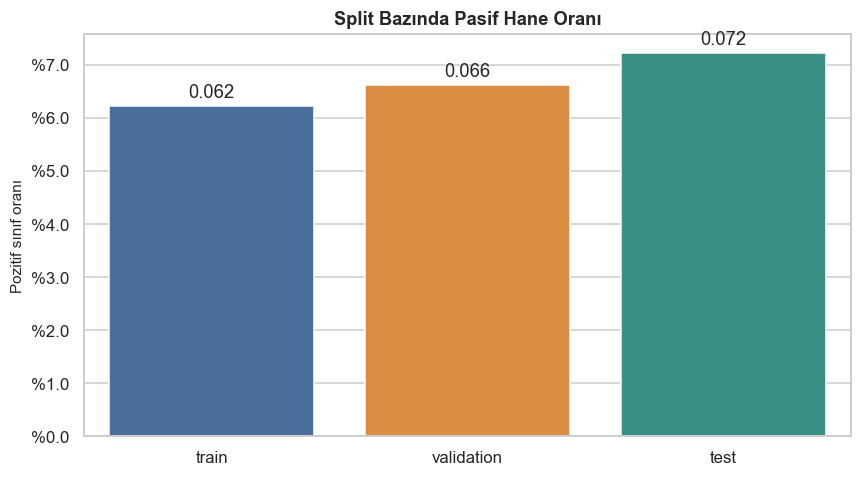

In [4]:
split_frames = {
    split_name: model_panel.loc[
        model_panel[SPLIT_COLUMN].eq(split_name)
    ].copy()
    for split_name in EXPECTED_SPLITS
}
train_data = split_frames["train"]
validation_data = split_frames["validation"]
test_data = split_frames["test"]

split_summary = (
    model_panel.groupby(SPLIT_COLUMN)
    .agg(
        rows=(TARGET_COLUMN, "size"),
        unique_households=("household_key", "nunique"),
        positive_rows=(TARGET_COLUMN, "sum"),
        positive_rate=(TARGET_COLUMN, "mean"),
        min_snapshot=("snapshot_day", "min"),
        max_snapshot=("snapshot_day", "max"),
    )
    .reindex(EXPECTED_SPLITS)
)

split_households = {
    split_name: set(frame["household_key"])
    for split_name, frame in split_frames.items()
}
household_overlap = pd.DataFrame([
    {
        "split_1": split_1,
        "split_2": split_2,
        "overlap_households": len(
            split_households[split_1] & split_households[split_2]
        ),
        "overlap_rate_of_split_2": len(
            split_households[split_1] & split_households[split_2]
        ) / len(split_households[split_2]),
    }
    for split_1, split_2 in [
        ("train", "validation"),
        ("train", "test"),
        ("validation", "test"),
    ]
])

train_snapshot_multiplicity = (
    train_data.groupby("household_key")
    .size()
    .value_counts()
    .sort_index()
    .rename_axis("train_snapshot_count")
    .rename("households")
    .reset_index()
)

display(split_summary)
display(household_overlap)
display(train_snapshot_multiplicity)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = split_summary.reset_index()
sns.barplot(
    data=plot_data,
    x=SPLIT_COLUMN,
    y="positive_rate",
    hue=SPLIT_COLUMN,
    palette=[COLORS["blue"], COLORS["orange"], COLORS["green"]],
    legend=False,
    ax=ax,
)
ax.set_title("Split Bazında Pasif Hane Oranı")
ax.set_xlabel("")
ax.set_ylabel("Pozitif sınıf oranı")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"%{value * 100:.1f}"))
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

### Aynı hanenin birden fazla split'te bulunması leakage mıdır?

Tek başına değildir. Projenin kullanım senaryosu mevcut haneleri ilerleyen
tarihlerde tekrar puanlamaktır. Her satırın feature'ları kendi snapshot gününde
kesildiği için gelecekteki işlem bilgisi geçmişe taşınmaz.

Ancak satırlar istatistiksel olarak bağımsız değildir. Bu nedenle:

- Random satır CV kullanılmaz.
- Hiperparametre tuning'i yalnızca ileri-zincirleme snapshot fold'larıyla yapılır.
- Test güven aralığı tek test snapshot'ındaki hane satırları üzerinden hesaplanır.
- `GroupKFold`, ancak daha önce hiç görülmemiş hanelere “cold-start” genellemesini
  ayrıca ölçmek istersek ikincil analiz olarak düşünülür.

## 5. Değerlendirme metrikleri

In [5]:
def safe_roc_auc(y_true, probability):
    if np.unique(y_true).size < 2:
        return np.nan
    return roc_auc_score(y_true, probability)


def top_k_metrics(y_true, probability, top_k_rate=TOP_K_RATE):
    y_true = np.asarray(y_true, dtype=int)
    probability = np.asarray(probability, dtype=float)
    top_k_count = max(1, math.ceil(len(y_true) * top_k_rate))
    ranked_indices = np.argsort(-probability, kind="mergesort")
    selected_indices = ranked_indices[:top_k_count]
    selected_positive_count = int(y_true[selected_indices].sum())
    all_positive_count = int(y_true.sum())
    recall_at_k = (
        selected_positive_count / all_positive_count
        if all_positive_count > 0 else np.nan
    )
    precision_at_k = selected_positive_count / top_k_count
    prevalence = y_true.mean()
    lift_at_k = precision_at_k / prevalence if prevalence > 0 else np.nan
    return {
        "top_k_rate": float(top_k_rate),
        "top_k_count": int(top_k_count),
        "positives_captured_at_top_k": selected_positive_count,
        "recall_at_top_k": float(recall_at_k),
        "precision_at_top_k": float(precision_at_k),
        "lift_at_top_k": float(lift_at_k),
    }


def ranking_metrics(y_true, probability, top_k_rate=TOP_K_RATE):
    y_true = np.asarray(y_true, dtype=int)
    probability = np.asarray(probability, dtype=float)
    metrics = {
        "average_precision": float(average_precision_score(y_true, probability)),
        "roc_auc": float(safe_roc_auc(y_true, probability)),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "positive_rate": float(y_true.mean()),
    }
    metrics.update(top_k_metrics(y_true, probability, top_k_rate))
    return metrics


def threshold_metrics(
    y_true,
    probability,
    threshold,
    top_k_rate=TOP_K_RATE,
):
    y_true = np.asarray(y_true, dtype=int)
    probability = np.asarray(probability, dtype=float)
    prediction = (probability >= threshold).astype(int)
    metrics = ranking_metrics(y_true, probability, top_k_rate)
    metrics.update({
        "threshold": float(threshold),
        "predicted_positive_rate": float(prediction.mean()),
        "precision": float(precision_score(y_true, prediction, zero_division=0)),
        "recall": float(recall_score(y_true, prediction, zero_division=0)),
        "f1": float(f1_score(y_true, prediction, zero_division=0)),
        "f2": float(fbeta_score(y_true, prediction, beta=2, zero_division=0)),
    })
    return metrics


def confusion_tables(y_true, probability, threshold):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    counts = confusion_matrix(y_true, prediction, labels=[0, 1])
    row_denominator = counts.sum(axis=1, keepdims=True)
    rates = np.divide(
        counts,
        row_denominator,
        out=np.zeros_like(counts, dtype=float),
        where=row_denominator != 0,
    )
    return counts, rates


def quantile_calibration_summary(y_true, probability, n_bins=CALIBRATION_N_BINS):
    """Class-1 ECE and the exact non-empty bins used by the reliability plot."""
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(probability, dtype=float)
    if y.ndim != 1 or p.ndim != 1 or len(y) != len(p) or len(y) == 0:
        raise ValueError("ECE requires non-empty aligned 1D arrays.")
    if not np.isfinite(y).all() or not np.isfinite(p).all():
        raise ValueError("ECE requires finite labels and probabilities.")
    if not np.isin(y, [0, 1]).all() or ((p < 0) | (p > 1)).any():
        raise ValueError("ECE requires binary labels and probabilities in [0, 1].")
    if not isinstance(n_bins, (int, np.integer)) or n_bins < 1:
        raise ValueError("n_bins must be a positive integer.")
    # Same quantile edges and left-search rule as sklearn.calibration_curve.
    edges = np.percentile(p, np.linspace(0, 1, n_bins + 1) * 100)
    bin_ids = np.searchsorted(edges[1:-1], p, side="left")
    rows = []
    for bin_id in np.unique(bin_ids):
        mask = bin_ids == bin_id
        mean_p = float(p[mask].mean())
        observed = float(y[mask].mean())
        gap = abs(mean_p - observed)
        weight = float(mask.mean())
        rows.append({
            "bin_id": int(bin_id + 1),
            "lower_edge": float(edges[bin_id]),
            "upper_edge": float(edges[bin_id + 1]),
            "rows": int(mask.sum()),
            "positive_rows": int(y[mask].sum()),
            "weight": weight,
            "mean_probability": mean_p,
            "observed_positive_rate": observed,
            "absolute_gap": gap,
            "weighted_gap": weight * gap,
        })
    bins = pd.DataFrame(rows)
    return float(bins["weighted_gap"].sum()), bins


def preserves_score_order(raw_probability, candidate_probability):
    """Reject reversals AND new ties between previously distinct scores."""
    raw = np.asarray(raw_probability, dtype=float)
    candidate = np.asarray(candidate_probability, dtype=float)
    if raw.shape != candidate.shape or not np.isfinite(candidate).all():
        return False
    order = np.argsort(raw, kind="mergesort")
    raw_delta = np.diff(raw[order])
    candidate_delta = np.diff(candidate[order])
    return bool(
        (candidate_delta[raw_delta > 0] > 0).all()
        and (candidate_delta[raw_delta == 0] == 0).all()
    )

### Metrikler nasıl okunmalı?

| Metrik | Bu projedeki anlamı |
|---|---|
| Average Precision (AP) | Dengesiz sınıfta Precision–Recall eğrisini özetleyen ana sıralama metriği |
| Recall | Gerçek pasif hanelerin ne kadarını yakaladığımız |
| Precision | Riskli dediğimiz hanelerin ne kadarının gerçekten pasif olduğu |
| F2 | Recall'a precision'dan daha fazla ağırlık veren threshold metriği |
| Brier score | Olasılık tahmininin doğruluğu; daha düşük daha iyi |
| Recall@top-k | Müdahale kapasitesi en riskli `%k` hane ise yakalanan pasif oranı |
| Lift@top-k | Top-k precision'ın rastgele hedeflemeye göre katı |

Accuracy ana metrik değildir. Pozitif oranı yaklaşık `%6–7` iken herkesi aktif
tahmin eden bir model yüksek accuracy gösterebilir ama hiçbir pasif haneyi yakalayamaz.

Kodda `average_precision_score` kullanılır. Bu değer günlük kullanımda sıkça
“PR-AUC” diye anılsa da teknik olarak trapezoid alan değil, recall artışlarıyla
ağırlıklandırılmış **Average Precision** değeridir. Rapor boyunca `AP` adıyla
sunulması daha doğrudur.

**F₂ formülü:**

$$
F_2 =
\frac{(1+2^2)\times \mathrm{Precision}\times \mathrm{Recall}}
{2^2\times \mathrm{Precision}+\mathrm{Recall}}
=
\frac{5\times \mathrm{Precision}\times \mathrm{Recall}}
{4\times \mathrm{Precision}+\mathrm{Recall}}
$$

F₂ skoru, **recall değerine precision değerinden daha fazla ağırlık verir**. Bu projede gerçekten pasifleşecek müşterilerin mümkün olduğunca çoğunu belirlemek daha önemli olduğu için eşik seçiminde F₂ skoru kullanılmıştır.

## 6. Preprocessing ve model pipeline'ları

In [6]:
CATEGORICAL_HINTS = set(target_design.get("categorical_features", []))


def split_feature_types(feature_names):
    categorical_features = [
        feature for feature in feature_names
        if feature in CATEGORICAL_HINTS
        or not pd.api.types.is_numeric_dtype(train_data[feature])
    ]
    numeric_features = [
        feature for feature in feature_names
        if feature not in categorical_features
    ]
    return numeric_features, categorical_features


def build_model_pipeline(feature_names, family, model_params=None):
    numeric_features, categorical_features = split_feature_types(feature_names)
    transformers = []

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if family == "logistic":
        numeric_steps.append(("scaler", StandardScaler()))
    if numeric_features:
        transformers.append((
            "numeric",
            Pipeline(numeric_steps),
            numeric_features,
        ))

    if categorical_features:
        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ])
        transformers.append((
            "categorical",
            categorical_pipeline,
            categorical_features,
        ))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

    if family == "logistic":
        estimator = LogisticRegression(
            class_weight=None,
            penalty="l2",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )
    elif family == "random_forest":
        estimator = RandomForestClassifier(
            n_estimators=250,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    else:
        raise ValueError(f"Bilinmeyen model ailesi: {family}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    if model_params:
        pipeline.set_params(**model_params)
    return pipeline


feature_type_summary = []
for feature_set_name in EXPECTED_FEATURE_SETS:
    numeric_features, categorical_features = split_feature_types(
        feature_sets[feature_set_name]
    )
    feature_type_summary.append({
        "feature_set": feature_set_name,
        "total": len(feature_sets[feature_set_name]),
        "numeric": len(numeric_features),
        "categorical": len(categorical_features),
    })
display(pd.DataFrame(feature_type_summary).sort_values("total"))

,feature_set,total,numeric,categorical
2,behavior_core_linear,37,37,0
0,behavior_core,38,38,0
1,behavior_plus_context,76,76,0
3,demographic_experiment,85,78,7


### Pipeline neden zorunlu?

Median doldurma, ölçekleme ve one-hot encoding model fit işlemiyle aynı pipeline
içindedir. Böylece bu dönüşümler yalnızca ilgili eğitim fold'unda öğrenilir;
validation veya test dağılımı imputation medyanına, ölçeğe ya da kategori
şemasına sızmaz.

- Logistic Regression sayısal değişkenlerde standardizasyon kullanır.
- Random Forest için ölçekleme uygulanmaz.
- Her iki modelde eksik sayısal değerler train medyanıyla doldurulur.
- Demografi deneyindeki kategoriler `handle_unknown="ignore"` ile kodlanır.
- Logistic Regression için `class_weight=None` ve `class_weight='balanced'`
  seçenekleri train içi ileri-zincirlemede karşılaştırılır.
- Random Forest `balanced_subsample` kullanır; test dağılımı yeniden örneklenmez.
- Hangi ağırlık seçilirse seçilsin ham model skoru, kalibrasyon doğrulanmadan
  gerçek pasiflik olasılığı olarak sunulmaz.

## 7. Train içinde ileri-zincirleme hiperparametre seçimi

In [7]:
train_snapshot_days = sorted(train_data["snapshot_day"].unique().tolist())
assert len(train_snapshot_days) >= 3, (
    "İleri-zincirleme tuning için en az üç train snapshot'ı gerekir."
)

INNER_FORWARD_FOLDS = [
    {
        "fold": f"{'_'.join(map(str, train_snapshot_days[:index]))}_to_{evaluation_day}",
        "fit_days": train_snapshot_days[:index],
        "evaluation_day": evaluation_day,
    }
    for index, evaluation_day in enumerate(train_snapshot_days[1:], start=1)
]

TUNING_SPECS = {
    "logistic": {
        "feature_set": "behavior_core_linear",
        "parameter_grid": {
            "model__C": [0.05, 0.20, 1.00, 5.00],
            "model__class_weight": [None, "balanced"],
        },
    },
    "random_forest": {
        "feature_set": "behavior_core",
        "parameter_grid": {
            "model__max_depth": [8, 12, None],
            "model__min_samples_leaf": [5, 15],
            "model__max_features": ["sqrt"],
            "model__class_weight": [None, "balanced_subsample"],
        },
    },
}

fold_summary = pd.DataFrame([
    {
        "fold": fold["fold"],
        "fit_days": str(fold["fit_days"]),
        "evaluation_day": fold["evaluation_day"],
        "fit_rows": int(train_data["snapshot_day"].isin(fold["fit_days"]).sum()),
        "evaluation_rows": int(train_data["snapshot_day"].eq(fold["evaluation_day"]).sum()),
    }
    for fold in INNER_FORWARD_FOLDS
])
display(fold_summary)

,fold,fit_days,evaluation_day,fit_rows,evaluation_rows
0,431_to_487,[431],487,2255,2276
1,431_487_to_543,"[431, 487]",543,4531,2273


### İleri-zincirleme neden kullanılıyor?

İlk fold geçmiş snapshot'tan bir sonraki snapshot'a, ikinci fold ise daha uzun
geçmişten en son train snapshot'ına tahmin yapar. Böylece model hiçbir fold'da
gelecekteki snapshot ile eğitilip geçmiş snapshot'ta sınanmaz.

Random Forest hiperparametreleri yalnızca `behavior_core` üzerinde seçilir.
Aynı seçilmiş ayarlar daha sonra context ve demografi feature setlerine uygulanır.
Bu sayede ablasyondaki performans farkı farklı tuning bütçesinden değil, eklenen
feature grubundan kaynaklanır.

Logistic Regression'da sınıf ağırlığı da hiperparametre olarak değerlendirilir.
`balanced` seçeneği sıralamayı güçlendirebilir fakat ham olasılıkları yukarı
çekebilir; `None` seçeneği ise doğal sınıf oranını korur. Seçim yine yalnızca
train fold'larındaki Average Precision'a göre yapılır. Olasılık büyüklüğü ayrı
bir kalibrasyon aşamasında ele alınır.

Aynı sınıf ağırlığı denetimi Random Forest için de uygulanır:
`None` ve `balanced_subsample` yalnızca train fold'larında karşılaştırılır.
RF grid'i 12 adaydan, Logistic grid'i 8 adaydan oluşur; iki ileri-zincirleme fold
korunur. RF'nin seçilen sınıf ağırlığı dahil bütün ayarları context ve demografi
ablasyonlarına aynı şekilde aktarılır. RF'nin varsayılanı `balanced_subsample`
olmaya devam eder; grid araması bu varsayılanı gerektiğinde değiştirir.

In [8]:
inner_cv_records = []
selected_hyperparameters = {}

for family, tuning_spec in TUNING_SPECS.items():
    feature_set_name = tuning_spec["feature_set"]
    feature_names = feature_sets[feature_set_name]
    parameter_candidates = list(ParameterGrid(tuning_spec["parameter_grid"]))

    for candidate_id, parameters in enumerate(parameter_candidates):
        for fold in INNER_FORWARD_FOLDS:
            fit_mask = train_data["snapshot_day"].isin(fold["fit_days"])
            evaluation_mask = train_data["snapshot_day"].eq(
                fold["evaluation_day"]
            )
            fold_fit = train_data.loc[fit_mask]
            fold_evaluation = train_data.loc[evaluation_mask]

            pipeline = build_model_pipeline(
                feature_names,
                family,
                model_params=parameters,
            )
            started_at = time.perf_counter()
            pipeline.fit(
                fold_fit[feature_names],
                fold_fit[TARGET_COLUMN],
            )
            fit_seconds = time.perf_counter() - started_at
            probability = pipeline.predict_proba(
                fold_evaluation[feature_names]
            )[:, 1]
            fold_metrics = ranking_metrics(
                fold_evaluation[TARGET_COLUMN],
                probability,
            )

            inner_cv_records.append({
                "family": family,
                "feature_set": feature_set_name,
                "candidate_id": candidate_id,
                "parameters": json.dumps(
                    parameters,
                    ensure_ascii=False,
                    sort_keys=True,
                ),
                "fold": fold["fold"],
                "fit_seconds": fit_seconds,
                **fold_metrics,
            })

    family_records = pd.DataFrame([
        record for record in inner_cv_records
        if record["family"] == family
    ])
    family_summary = (
        family_records.groupby(
            ["candidate_id", "parameters"], as_index=False
        )
        .agg(
            mean_average_precision=("average_precision", "mean"),
            std_average_precision=("average_precision", "std"),
            mean_brier_score=("brier_score", "mean"),
            mean_recall_at_top_k=("recall_at_top_k", "mean"),
            mean_fit_seconds=("fit_seconds", "mean"),
        )
        .sort_values(
            ["mean_average_precision", "mean_brier_score"],
            ascending=[False, True],
        )
    )
    best_candidate_id = int(family_summary.iloc[0]["candidate_id"])
    selected_hyperparameters[family] = parameter_candidates[best_candidate_id]

inner_cv_results = pd.DataFrame(inner_cv_records)
inner_cv_summary = (
    inner_cv_results.groupby(
        ["family", "feature_set", "candidate_id", "parameters"],
        as_index=False,
    )
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_brier_score=("brier_score", "mean"),
        mean_recall_at_top_k=("recall_at_top_k", "mean"),
        mean_fit_seconds=("fit_seconds", "mean"),
    )
    .sort_values(
        ["family", "mean_average_precision", "mean_brier_score"],
        ascending=[True, False, True],
    )
)

print("Seçilen hiperparametreler:")
display(pd.Series(selected_hyperparameters).to_frame("parameters"))
display(inner_cv_summary)

# Each weight setting contributes its AP-first best tuned configuration.
class_weight_audit = inner_cv_summary.copy()
class_weight_audit["class_weight"] = class_weight_audit["parameters"].map(
    lambda value: str(json.loads(value)["model__class_weight"])
)
class_weight_audit = (
    class_weight_audit.sort_values(
        ["mean_average_precision", "mean_brier_score", "candidate_id"],
        ascending=[False, True, True],
    )
    .drop_duplicates(["family", "class_weight"])
    .sort_values(["family", "class_weight"])
    .reset_index(drop=True)
)
class_weight_audit["selected_within_family"] = class_weight_audit.apply(
    lambda row: json.loads(row["parameters"])
    == selected_hyperparameters[row["family"]],
    axis=1,
)

class_weight_audit_finding = {}
for family, weighted_label in [
    ("logistic", "balanced"),
    ("random_forest", "balanced_subsample"),
]:
    family_audit = class_weight_audit.loc[
        class_weight_audit["family"].eq(family)
    ].set_index("class_weight")
    native = family_audit.loc["None"]
    weighted = family_audit.loc[weighted_label]
    ap_delta = native["mean_average_precision"] - weighted["mean_average_precision"]
    brier_delta = native["mean_brier_score"] - weighted["mean_brier_score"]
    if ap_delta > 0 and brier_delta < 0:
        conclusion = "Ağırlıksız aday hem AP hem Brier bakımından daha iyi."
    elif ap_delta < 0 and brier_delta > 0:
        conclusion = "Ağırlıklı aday hem AP hem Brier bakımından daha iyi."
    else:
        conclusion = "İki metrik ortak bir üstünlük göstermiyor (ödünleşim/eşitlik)."
    class_weight_audit_finding[family] = (
        f"{family}: class_weight=None için train-CV AP="
        f"{native['mean_average_precision']:.4f}, Brier="
        f"{native['mean_brier_score']:.4f}; {weighted_label} için AP="
        f"{weighted['mean_average_precision']:.4f}, Brier="
        f"{weighted['mean_brier_score']:.4f}. {conclusion} "
        "Her sınıf ağırlığı seçeneğinin AP ile seçilmiş en iyi ayarları "
        "karşılaştırılmıştır; bu, tek başına sınıf ağırlığının nedensel etkisi "
        "veya istatistiksel anlamlılık testi değildir. Yalnızca iki fold vardır."
    )

display(class_weight_audit[[
    "family", "class_weight", "parameters", "mean_average_precision",
    "mean_brier_score", "selected_within_family",
]])

Seçilen hiperparametreler:


,parameters
logistic,"{'model__C': 0.2, 'model__class_weight': None}"
random_forest,"{'model__class_weight': None, 'model__max_dept..."


,family,feature_set,candidate_id,parameters,mean_average_precision,std_average_precision,mean_brier_score,mean_recall_at_top_k,mean_fit_seconds
2,logistic,behavior_core_linear,2,"{""model__C"": 0.2, ""model__class_weight"": null}",0.3501,0.0567,0.0485,0.4993,0.0340
0,logistic,behavior_core_linear,0,"{""model__C"": 0.05, ""model__class_weight"": null}",0.3473,0.0580,0.0490,0.5070,0.0274
4,logistic,behavior_core_linear,4,"{""model__C"": 1.0, ""model__class_weight"": null}",0.3470,0.0483,0.0485,0.4963,0.0373
6,logistic,behavior_core_linear,6,"{""model__C"": 5.0, ""model__class_weight"": null}",0.3426,0.0417,0.0487,0.5033,0.0487
1,logistic,behavior_core_linear,1,"{""model__C"": 0.05, ""model__class_weight"": ""bal...",0.3421,0.0386,0.1542,0.5000,0.0243
3,logistic,behavior_core_linear,3,"{""model__C"": 0.2, ""model__class_weight"": ""bala...",0.3398,0.0288,0.1519,0.4893,0.0356
5,logistic,behavior_core_linear,5,"{""model__C"": 1.0, ""model__class_weight"": ""bala...",0.3363,0.0210,0.1518,0.4937,0.0374
7,logistic,behavior_core_linear,7,"{""model__C"": 5.0, ""model__class_weight"": ""bala...",0.3339,0.0164,0.1521,0.4937,0.0378
8,random_forest,behavior_core,0,"{""model__class_weight"": null, ""model__max_dept...",0.3588,0.0763,0.0483,0.5141,0.4671
10,random_forest,behavior_core,2,"{""model__class_weight"": null, ""model__max_dept...",0.3586,0.0742,0.0483,0.5100,0.4153


,family,class_weight,parameters,mean_average_precision,mean_brier_score,selected_within_family
0,logistic,None,"{""model__C"": 0.2, ""model__class_weight"": null}",0.3501,0.0485,True
1,logistic,balanced,"{""model__C"": 0.05, ""model__class_weight"": ""bal...",0.3421,0.1542,False
2,random_forest,None,"{""model__class_weight"": null, ""model__max_dept...",0.3588,0.0483,True
3,random_forest,balanced_subsample,"{""model__class_weight"": ""balanced_subsample"", ...",0.3334,0.0913,False


### Tuning tablosu nasıl okunmalı?

Ana sıralama ölçütü fold'ların ortalama `average_precision` değeridir. Tam eşitlik
durumunda daha düşük Brier score tercih edilir. Fold sayısı yalnızca iki
olduğu için küçük skor farkları kesin üstünlük olarak yorumlanmamalıdır;
hiperparametre uzayı bu nedenle bilinçli olarak küçük tutulmuştur.

## 8. Validation için aday modeller ve feature ablasyonları

In [9]:
CANDIDATE_SPECS = [
    {
        "model_name": "logistic_core",
        "family": "logistic",
        "feature_set": "behavior_core_linear",
    },
    {
        "model_name": "rf_core",
        "family": "random_forest",
        "feature_set": "behavior_core",
    },
    {
        "model_name": "rf_context",
        "family": "random_forest",
        "feature_set": "behavior_plus_context",
    },
    {
        "model_name": "rf_demographic",
        "family": "random_forest",
        "feature_set": "demographic_experiment",
    },
]

fitted_models = {}
candidate_probabilities_validation = {}
validation_records = []

y_train = train_data[TARGET_COLUMN].astype(int)
y_validation = validation_data[TARGET_COLUMN].astype(int)

dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(np.zeros((len(train_data), 1)), y_train)
dummy_validation_probability = dummy_model.predict_proba(
    np.zeros((len(validation_data), 1))
)[:, 1]
dummy_metrics = ranking_metrics(
    y_validation,
    dummy_validation_probability,
)
validation_records.append({
    "model_name": "dummy_prior",
    "family": "dummy",
    "feature_set": "none",
    "feature_count": 0,
    "fit_seconds": 0.0,
    "probability_stage": "prior_baseline",
    **dummy_metrics,
})

for candidate_spec in CANDIDATE_SPECS:
    model_name = candidate_spec["model_name"]
    family = candidate_spec["family"]
    feature_set_name = candidate_spec["feature_set"]
    feature_names = feature_sets[feature_set_name]

    pipeline = build_model_pipeline(
        feature_names,
        family,
        model_params=selected_hyperparameters[family],
    )
    started_at = time.perf_counter()
    pipeline.fit(train_data[feature_names], y_train)
    fit_seconds = time.perf_counter() - started_at
    validation_probability = pipeline.predict_proba(
        validation_data[feature_names]
    )[:, 1]
    metrics = ranking_metrics(y_validation, validation_probability)

    fitted_models[model_name] = pipeline
    candidate_probabilities_validation[model_name] = validation_probability
    validation_records.append({
        "model_name": model_name,
        "family": family,
        "feature_set": feature_set_name,
        "feature_count": len(feature_names),
        "fit_seconds": fit_seconds,
        "probability_stage": "raw_uncalibrated",
        **metrics,
    })

validation_model_comparison = pd.DataFrame(validation_records)
dummy_average_precision = float(
    validation_model_comparison.loc[
        validation_model_comparison["model_name"].eq("dummy_prior"),
        "average_precision",
    ].iloc[0]
)
validation_model_comparison["ap_gain_over_dummy"] = (
    validation_model_comparison["average_precision"]
    - dummy_average_precision
)
validation_model_comparison = validation_model_comparison.sort_values(
    ["average_precision", "brier_score"],
    ascending=[False, True],
).reset_index(drop=True)

rf_core_ap = float(
    validation_model_comparison.loc[
        validation_model_comparison["model_name"].eq("rf_core"),
        "average_precision",
    ].iloc[0]
)
rf_ablation = (
    validation_model_comparison.loc[
        validation_model_comparison["family"].eq("random_forest")
    ]
    .copy()
    .assign(
        ap_delta_vs_rf_core=lambda frame: frame["average_precision"] - rf_core_ap
    )
    [[
        "model_name", "feature_set", "feature_count",
        "average_precision", "ap_delta_vs_rf_core",
        "brier_score", "recall_at_top_k", "lift_at_top_k",
    ]]
)

display(validation_model_comparison)
print("Random Forest feature ablasyonu:")
display(rf_ablation)

,model_name,family,feature_set,feature_count,fit_seconds,probability_stage,average_precision,roc_auc,brier_score,positive_rate,top_k_rate,top_k_count,positives_captured_at_top_k,recall_at_top_k,precision_at_top_k,lift_at_top_k,ap_gain_over_dummy
0,logistic_core,logistic,behavior_core_linear,37,0.0875,raw_uncalibrated,0.3143,0.8677,0.0522,0.0661,0.1000,227,66,0.4400,0.2907,4.3961,0.2482
1,rf_core,random_forest,behavior_core,38,0.6068,raw_uncalibrated,0.2962,0.8683,0.0529,0.0661,0.1000,227,70,0.4667,0.3084,4.6626,0.2300
2,rf_context,random_forest,behavior_plus_context,76,0.6381,raw_uncalibrated,0.2847,0.8647,0.0532,0.0661,0.1000,227,69,0.4600,0.3040,4.5959,0.2185
3,rf_demographic,random_forest,demographic_experiment,85,0.7241,raw_uncalibrated,0.2801,0.8662,0.0531,0.0661,0.1000,227,72,0.4800,0.3172,4.7958,0.2140
4,dummy_prior,dummy,none,0,0.0000,prior_baseline,0.0661,0.5000,0.0618,0.0661,0.1000,227,12,0.0800,0.0529,0.7993,0.0000


Random Forest feature ablasyonu:


,model_name,feature_set,feature_count,average_precision,ap_delta_vs_rf_core,brier_score,recall_at_top_k,lift_at_top_k
1,rf_core,behavior_core,38,0.2962,0.0000,0.0529,0.4667,4.6626
2,rf_context,behavior_plus_context,76,0.2847,-0.0115,0.0532,0.4600,4.5959
3,rf_demographic,demographic_experiment,85,0.2801,-0.0161,0.0531,0.4800,4.7958


### Ablasyonun amacı

- `rf_core → rf_context` farkı ürün/kategori, kampanya, kupon ve demografi kaydı
  göstergelerinin ek katkısını ölçer.
- `rf_context → rf_demographic` farkı anonim demografik kategorilerin ek katkısını
  ölçer.
- Bütün Random Forest deneyleri aynı hiperparametrelerle çalıştığı için kıyaslama
  daha adildir.

Ek feature sayısı artarken PR-AUC artmıyor veya Brier score kötüleşiyorsa daha
karmaşık set otomatik olarak tercih edilmemelidir.

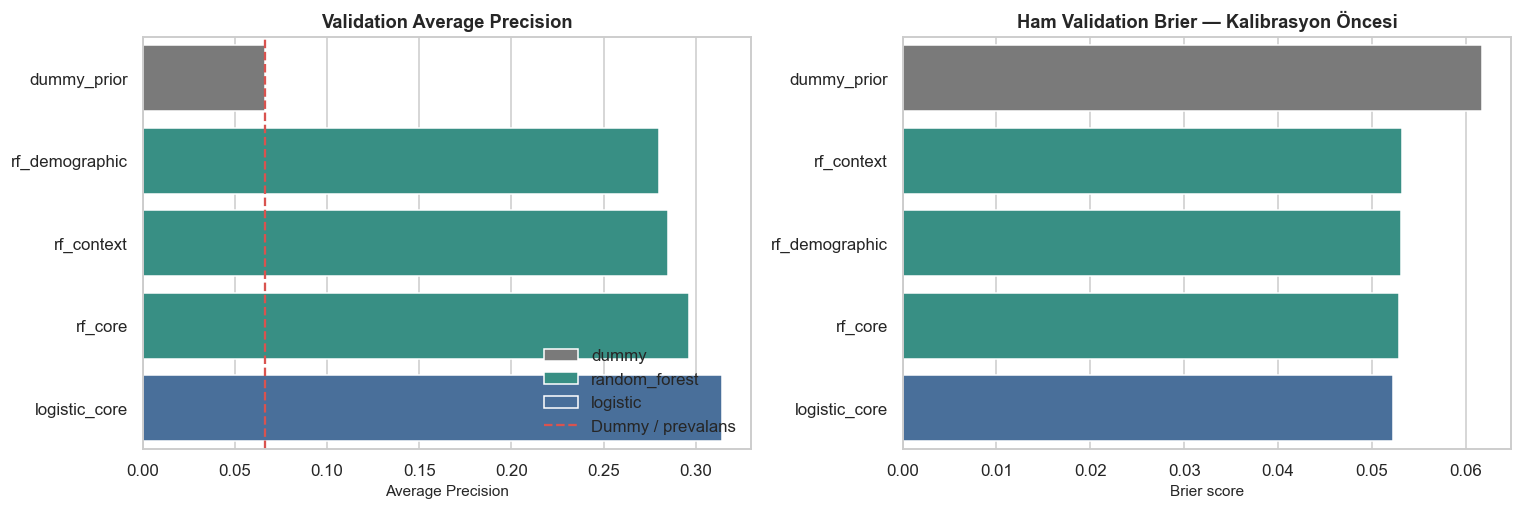

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

comparison_plot = validation_model_comparison.sort_values(
    "average_precision", ascending=True
)
sns.barplot(
    data=comparison_plot,
    x="average_precision",
    y="model_name",
    hue="family",
    dodge=False,
    palette={
        "dummy": COLORS["gray"],
        "logistic": COLORS["blue"],
        "random_forest": COLORS["green"],
    },
    ax=axes[0],
)
axes[0].axvline(
    dummy_average_precision,
    color=COLORS["red"],
    linestyle="--",
    label="Dummy / prevalans",
)
axes[0].set_title("Validation Average Precision")
axes[0].set_xlabel("Average Precision")
axes[0].set_ylabel("")
axes[0].legend(loc="lower right")

comparison_brier = validation_model_comparison.sort_values(
    "brier_score", ascending=False
)
sns.barplot(
    data=comparison_brier,
    x="brier_score",
    y="model_name",
    hue="family",
    dodge=False,
    palette={
        "dummy": COLORS["gray"],
        "logistic": COLORS["blue"],
        "random_forest": COLORS["green"],
    },
    ax=axes[1],
)
axes[1].set_title("Ham Validation Brier — Kalibrasyon Öncesi")
axes[1].set_xlabel("Brier score")
axes[1].set_ylabel("")
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

plt.tight_layout()
plt.show()

### Model karşılaştırması nasıl okunmalı?

Ana model seçim metriği validation Average Precision'dır; çünkü ilk amaç riskli
haneleri doğru sıralamaktır. Bu tablodaki eğitilmiş modellere ait Brier değerleri
ham `predict_proba` skorlarına aittir. Özellikle `class_weight='balanced'`, azınlık
sınıfına daha fazla kayıp ağırlığı verdiği için bu skorların büyüklüğünü gerçek
pasiflik oranının üzerine taşıyabilir.

Bu nedenle iyi sıralayan bir model yalnızca ham Brier nedeniyle doğrudan elenmez.
Önce AP ile tek model seçilir. Ardından modelin doğal olasılığı ile yalnızca train
out-of-fold tahminlerinden öğrenilen Platt adayı validation'da karşılaştırılır.
Platt dönüşümü doğal olasılığı iyileştirmiyorsa zorla uygulanmaz; daha düşük
validation Brier'a sahip yöntem dondurulur. Customer 360 ve chatbot yalnızca son
kalite kapısını geçen `lapse_probability` alanını kullanabilir.

## 9. Validation üzerinden tek modelin seçilmesi

In [11]:
eligible_validation_results = validation_model_comparison.loc[
    ~validation_model_comparison["family"].eq("dummy")
].copy()
selected_row = (
    eligible_validation_results.sort_values(
        ["average_precision", "brier_score", "feature_count"],
        ascending=[False, True, True],
    )
    .iloc[0]
)

SELECTED_MODEL_NAME = selected_row["model_name"]
SELECTED_FAMILY = selected_row["family"]
SELECTED_FEATURE_SET = selected_row["feature_set"]
SELECTED_FEATURES = feature_sets[SELECTED_FEATURE_SET]
SELECTED_MODEL = fitted_models[SELECTED_MODEL_NAME]
SELECTED_VALIDATION_RAW_SCORE = candidate_probabilities_validation[
    SELECTED_MODEL_NAME
]

selection_summary = pd.Series({
    "selected_model": SELECTED_MODEL_NAME,
    "family": SELECTED_FAMILY,
    "feature_set": SELECTED_FEATURE_SET,
    "feature_count": len(SELECTED_FEATURES),
    "validation_average_precision": float(selected_row["average_precision"]),
    "validation_raw_brier_score": float(selected_row["brier_score"]),
    "validation_recall_at_top_10pct": float(selected_row["recall_at_top_k"]),
    "validation_lift_at_top_10pct": float(selected_row["lift_at_top_k"]),
})
display(selection_summary.to_frame("value"))

,value
selected_model,logistic_core
family,logistic
feature_set,behavior_core_linear
feature_count,37
validation_average_precision,0.3143
validation_raw_brier_score,0.0522
validation_recall_at_top_10pct,0.4400
validation_lift_at_top_10pct,4.3961


### Seçim kuralı

Dummy model seçime dahil edilmez; yalnızca referanstır. Aday modeller önce
Average Precision, sonra ham Brier score, sonra daha az feature kullanımıyla
sıralanır. Average Precision yalnızca skor sırasına bağlı olduğu için seçilen
modelin `predict_proba` büyüklüğünün doğru kalibre edildiğini göstermez.

Bu hücrede yalnızca `SELECTED_MODEL` ve `SELECTED_VALIDATION_RAW_SCORE`
sabitlenmiştir. Aşağıda train OOF skorlarından bir Platt adayı öğrenilecek;
validation, doğal olasılık ile Platt arasından daha düşük Brier'a sahip yöntemi
seçecektir. Test verisine hâlâ dokunulmamıştır.

### Olasılık kalibrasyonu: Native, Platt ve Isotonic

Olasılık kalibrasyonu, modelin ürettiği risk olasılıklarının gerçekleşen oranlarla uyumunu ifade eder. Örneğin modelin yaklaşık `%30` risk verdiği müşterilerin yaklaşık `%30`'unun gerçekten pasifleşmesi beklenir.

- **`native_raw`:** Modelin herhangi bir düzeltme uygulanmamış ham olasılıklarıdır.
- **Platt scaling:** Ham skorları sigmoid bir fonksiyonla olasılığa dönüştürür. Az veride genellikle daha kararlı olduğu ve sıralamayı koruduğu için bu çalışmada `platt_oof` aday olarak kullanılmıştır.
- **Isotonic regression:** Belirli bir fonksiyon biçimi varsaymadan monoton bir dönüşüm öğrenir. Daha esnektir; ancak az veride aşırı öğrenebilir ve farklı ham skorları aynı olasılığa eşleyerek sıralamayı etkileyebilir. Bu nedenle mevcut sürümde seçim adaylarına dahil edilmemiştir.

Kalibratör yalnızca eğitim verisinden elde edilen **out-of-fold tahminlerle** öğrenilerek veri sızıntısı riski azaltılmıştır.

### Brier skoru

Brier skoru, tahmin edilen olasılıklarla gerçek sınıflar arasındaki ortalama karesel hatadır:

$$
\mathrm{Brier}
=
\frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2
$$

Daha düşük Brier skoru daha iyidir. Ancak skor hem kalibrasyondan hem de modelin sınıfları ayırma başarısından etkilenir. Bu nedenle aynı test kümesindeki dummy modelle karşılaştırılır.

### Expected Calibration Error (ECE)

ECE, olasılık gruplarındaki ortalama tahmin ile gerçekleşen pozitif oranı arasındaki farkı ölçer:

$$
\mathrm{ECE}
=
\sum_{b=1}^{B}
\frac{n_b}{N}
\left|\overline{p}_b-\overline{y}_b\right|
$$

Daha düşük ECE daha iyi kalibrasyona işaret eder. Örneğin `ECE = 0.02`, kullanılan binleme yönteminde tahminlerle gerçekleşen oranlar arasındaki ağırlıklı ortalama farkın yaklaşık **2 yüzde puan** olduğunu gösterir; modelin `%98 güvenilir` olduğu anlamına gelmez.

Bu çalışmada ECE, 10 quantile bin ve güvenilirlik eğrisiyle birlikte tanısal amaçla kullanılır. Nihai seçim yalnızca ECE’ye göre değil; **AP, top-k recall, Brier ve ECE** birlikte değerlendirilerek yapılır.

In [12]:
print("Güncel train-CV sınıf ağırlığı bulgusu:\n")
print("\n\n".join(class_weight_audit_finding.values()))

PROBABILITY_CLIP_EPSILON = 1e-6


def probability_to_logit_feature(
    probability,
    epsilon=PROBABILITY_CLIP_EPSILON,
):
    probability = np.asarray(probability, dtype=float)
    clipped = np.clip(probability, epsilon, 1 - epsilon)
    return np.log(clipped / (1 - clipped)).reshape(-1, 1)


def apply_probability_calibrator(calibrator, raw_probability):
    return calibrator.predict_proba(
        probability_to_logit_feature(raw_probability)
    )[:, 1]


calibration_oof_frames = []
for fold in INNER_FORWARD_FOLDS:
    fit_mask = train_data["snapshot_day"].isin(fold["fit_days"])
    evaluation_mask = train_data["snapshot_day"].eq(fold["evaluation_day"])
    fold_fit = train_data.loc[fit_mask]
    fold_evaluation = train_data.loc[evaluation_mask]

    fold_model = build_model_pipeline(
        SELECTED_FEATURES,
        SELECTED_FAMILY,
        model_params=selected_hyperparameters[SELECTED_FAMILY],
    )
    fold_model.fit(
        fold_fit[SELECTED_FEATURES],
        fold_fit[TARGET_COLUMN],
    )
    fold_raw_score = fold_model.predict_proba(
        fold_evaluation[SELECTED_FEATURES]
    )[:, 1]

    fold_output = fold_evaluation[
        ["household_key", "snapshot_day", TARGET_COLUMN]
    ].copy()
    fold_output["calibration_fold"] = fold["fold"]
    fold_output["raw_model_score"] = fold_raw_score
    calibration_oof_frames.append(fold_output)

calibration_oof_predictions = pd.concat(
    calibration_oof_frames,
    ignore_index=True,
)

assert set(calibration_oof_predictions["snapshot_day"]).issubset(
    set(split_days["train"])
)
assert calibration_oof_predictions["snapshot_day"].max() < min(
    split_days["validation"]
)
assert calibration_oof_predictions[TARGET_COLUMN].nunique() == 2
assert calibration_oof_predictions["raw_model_score"].between(0, 1).all()

PROBABILITY_CALIBRATOR = LogisticRegression(
    C=1.0,
    class_weight=None,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
PROBABILITY_CALIBRATOR.fit(
    probability_to_logit_feature(
        calibration_oof_predictions["raw_model_score"]
    ),
    calibration_oof_predictions[TARGET_COLUMN],
)
calibration_oof_predictions["platt_probability_in_sample"] = (
    apply_probability_calibrator(
        PROBABILITY_CALIBRATOR,
        calibration_oof_predictions["raw_model_score"],
    )
)

PLATT_VALIDATION_PROBABILITY = apply_probability_calibrator(
    PROBABILITY_CALIBRATOR,
    SELECTED_VALIDATION_RAW_SCORE,
)

calibration_audit = pd.Series({
    "calibration_rows": len(calibration_oof_predictions),
    "calibration_positive_rows": int(calibration_oof_predictions[TARGET_COLUMN].sum()),
    "calibration_unique_households": int(
        calibration_oof_predictions["household_key"].nunique()
    ),
    "calibration_snapshot_days": sorted(
        calibration_oof_predictions["snapshot_day"].unique().tolist()
    ),
    "latest_calibration_day": int(
        calibration_oof_predictions["snapshot_day"].max()
    ),
    "first_validation_day": int(min(split_days["validation"])),
    "platt_slope": float(PROBABILITY_CALIBRATOR.coef_[0, 0]),
    "platt_intercept": float(PROBABILITY_CALIBRATOR.intercept_[0]),
    "monotonic_increasing": bool(PROBABILITY_CALIBRATOR.coef_[0, 0] > 0),
})
display(calibration_audit.to_frame("value"))
if not calibration_audit["monotonic_increasing"]:
    warnings.warn(
        "Platt adayının eğimi pozitif değil; risk sırasını tersine "
        "çevirebileceği için yöntem seçiminden çıkarılacaktır."
    )

Güncel train-CV sınıf ağırlığı bulgusu:

logistic: class_weight=None için train-CV AP=0.3501, Brier=0.0485; balanced için AP=0.3421, Brier=0.1542. Ağırlıksız aday hem AP hem Brier bakımından daha iyi. Her sınıf ağırlığı seçeneğinin AP ile seçilmiş en iyi ayarları karşılaştırılmıştır; bu, tek başına sınıf ağırlığının nedensel etkisi veya istatistiksel anlamlılık testi değildir. Yalnızca iki fold vardır.

random_forest: class_weight=None için train-CV AP=0.3588, Brier=0.0483; balanced_subsample için AP=0.3334, Brier=0.0913. Ağırlıksız aday hem AP hem Brier bakımından daha iyi. Her sınıf ağırlığı seçeneğinin AP ile seçilmiş en iyi ayarları karşılaştırılmıştır; bu, tek başına sınıf ağırlığının nedensel etkisi veya istatistiksel anlamlılık testi değildir. Yalnızca iki fold vardır.


,value
calibration_rows,4549
calibration_positive_rows,285
calibration_unique_households,2352
calibration_snapshot_days,"[487, 543]"
latest_calibration_day,543
first_validation_day,599
platt_slope,1.0880
platt_intercept,-0.0041
monotonic_increasing,True


,score_name,selection_eligible,rank_preserved,ece_quantile,effective_calibration_bins,mean_predicted_probability,observed_positive_rate,absolute_prevalence_gap,min_probability,median_probability,p90_probability,max_probability,average_precision,brier_score,selected_for_test
0,dummy_prior,False,False,0.0040,1,0.0622,0.0661,0.0040,0.0622,0.0622,0.0622,0.0622,0.0661,0.0618,False
1,native_raw,True,True,0.0110,10,0.0611,0.0661,0.0050,0.0002,0.0176,0.1927,0.9414,0.3143,0.0522,True
2,platt_oof,True,True,0.0139,10,0.0538,0.0661,0.0124,0.0001,0.0123,0.1733,0.9534,0.3143,0.0525,False


,value
selected_probability_method,native_raw
validation_raw_brier,0.0522
validation_platt_brier,0.0525
validation_selected_brier,0.0522
validation_dummy_brier,0.0618
selected_ece_quantile,0.0110
selected_mean_probability,0.0611
observed_positive_rate,0.0661


,passed
platt_candidate_uses_train_oof_only,True
selected_method_is_eligible,True
selected_method_preserves_rank,True
selected_probability_is_finite,True
selected_probability_is_bounded,True
selected_brier_not_worse_than_raw,True
selected_brier_below_dummy,True
probability_ready_for_customer_360,True


Validation güvenilirlik binleri — ECE ve grafiğin ortak kaynağı:


,score_name,bin_id,lower_edge,upper_edge,rows,positive_rows,weight,mean_probability,observed_positive_rate,absolute_gap,weighted_gap
0,dummy_prior,1,0.0622,0.0622,2268,150,1.0000,0.0622,0.0661,0.0040,0.0040
1,native_raw,1,0.0002,0.0020,227,0,0.1001,0.0013,0.0000,0.0013,0.0001
2,native_raw,2,0.0020,0.0035,227,0,0.1001,0.0027,0.0000,0.0027,0.0003
3,native_raw,3,0.0035,0.0056,227,3,0.1001,0.0045,0.0132,0.0087,0.0009
4,native_raw,4,0.0056,0.0096,226,1,0.0996,0.0075,0.0044,0.0030,0.0003
5,native_raw,5,0.0096,0.0176,227,1,0.1001,0.0133,0.0044,0.0089,0.0009
6,native_raw,6,0.0176,0.0307,227,5,0.1001,0.0236,0.0220,0.0016,0.0002
7,native_raw,7,0.0307,0.0531,226,11,0.0996,0.0406,0.0487,0.0081,0.0008
8,native_raw,8,0.0531,0.1004,227,19,0.1001,0.0743,0.0837,0.0094,0.0009
9,native_raw,9,0.1004,0.1927,227,44,0.1001,0.1397,0.1938,0.0541,0.0054


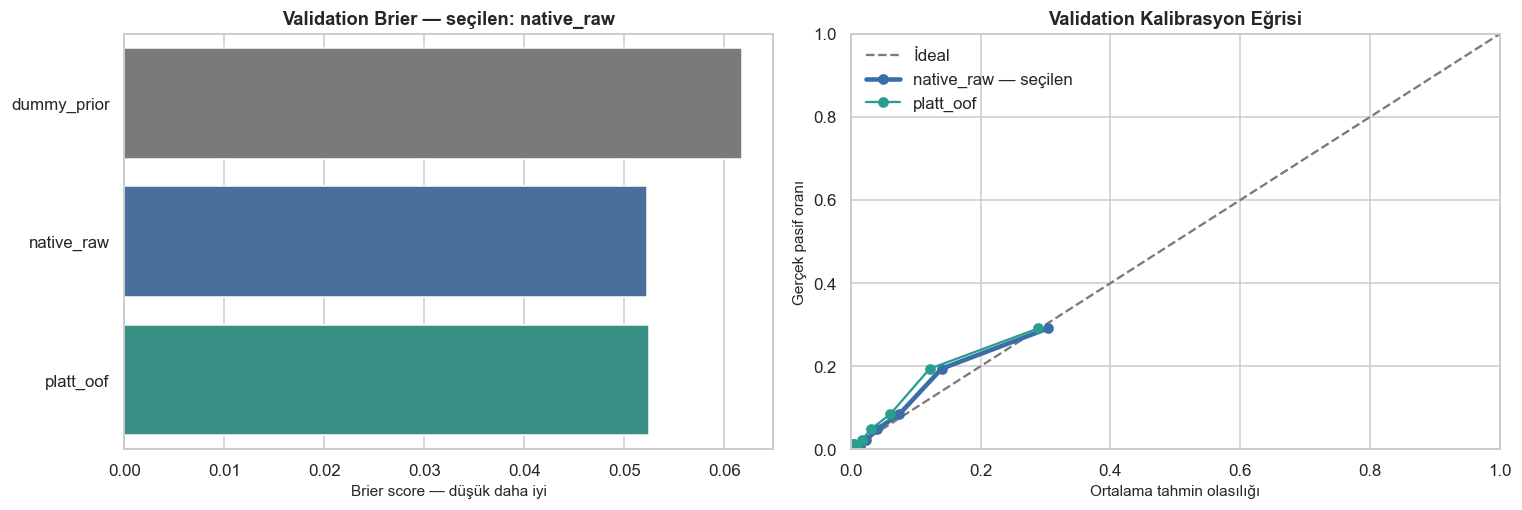

In [13]:
VALIDATION_PROBABILITY_CANDIDATES = {
    "native_raw": SELECTED_VALIDATION_RAW_SCORE,
    "platt_oof": PLATT_VALIDATION_PROBABILITY,
}

calibration_validation_records = []
validation_calibration_bin_frames = []
for score_name, probability in {
    "dummy_prior": dummy_validation_probability,
    **VALIDATION_PROBABILITY_CANDIDATES,
}.items():
    metrics = ranking_metrics(y_validation, probability)
    ece, reliability_bins = quantile_calibration_summary(y_validation, probability)
    reliability_bins.insert(0, "score_name", score_name)
    validation_calibration_bin_frames.append(reliability_bins)
    rank_preserved = preserves_score_order(SELECTED_VALIDATION_RAW_SCORE, probability)
    calibration_validation_records.append({
        "score_name": score_name,
        "selection_eligible": (
            score_name == "native_raw"
            or (
                score_name == "platt_oof"
                and calibration_audit["monotonic_increasing"]
                and rank_preserved
            )
        ),
        "rank_preserved": rank_preserved,
        "ece_quantile": ece,
        "effective_calibration_bins": len(reliability_bins),
        "mean_predicted_probability": float(np.mean(probability)),
        "observed_positive_rate": float(y_validation.mean()),
        "absolute_prevalence_gap": float(
            abs(np.mean(probability) - y_validation.mean())
        ),
        "min_probability": float(np.min(probability)),
        "median_probability": float(np.median(probability)),
        "p90_probability": float(np.quantile(probability, 0.90)),
        "max_probability": float(np.max(probability)),
        "average_precision": metrics["average_precision"],
        "brier_score": metrics["brier_score"],
    })

calibration_validation_comparison = pd.DataFrame(
    calibration_validation_records
)
validation_calibration_bins = pd.concat(
    validation_calibration_bin_frames, ignore_index=True
)


def metric_for_probability_candidate(score_name, metric_name):
    return float(
        calibration_validation_comparison.loc[
            calibration_validation_comparison["score_name"].eq(score_name),
            metric_name,
        ].iloc[0]
    )


raw_validation_brier = metric_for_probability_candidate(
    "native_raw", "brier_score"
)
platt_validation_brier = metric_for_probability_candidate(
    "platt_oof", "brier_score"
)
dummy_validation_brier = metric_for_probability_candidate(
    "dummy_prior", "brier_score"
)

# Brier eşitliğinde ek dönüşüm uygulamayan daha basit yöntem seçilir.
probability_method_priority = {"native_raw": 0, "platt_oof": 1}
eligible_probability_methods = calibration_validation_comparison.loc[
    calibration_validation_comparison["selection_eligible"]
].copy()
eligible_probability_methods["method_priority"] = (
    eligible_probability_methods["score_name"].map(probability_method_priority)
)
selected_probability_row = (
    eligible_probability_methods.sort_values(
        ["brier_score", "method_priority"],
        ascending=[True, True],
    )
    .iloc[0]
)

SELECTED_PROBABILITY_METHOD = str(selected_probability_row["score_name"])
SELECTED_VALIDATION_PROBABILITY = VALIDATION_PROBABILITY_CANDIDATES[
    SELECTED_PROBABILITY_METHOD
]
SELECTED_PROBABILITY_CALIBRATOR = (
    PROBABILITY_CALIBRATOR
    if SELECTED_PROBABILITY_METHOD == "platt_oof"
    else None
)
SELECTED_PROBABILITY_INPUT_TRANSFORM = (
    "logit(clipped raw positive-class probability)"
    if SELECTED_PROBABILITY_METHOD == "platt_oof"
    else "identity"
)

selected_validation_brier = float(selected_probability_row["brier_score"])
selected_validation_mean_probability = float(
    selected_probability_row["mean_predicted_probability"]
)
calibration_rank_preserved = preserves_score_order(
    SELECTED_VALIDATION_RAW_SCORE, SELECTED_VALIDATION_PROBABILITY
)
selected_probability_is_finite = bool(
    np.isfinite(SELECTED_VALIDATION_PROBABILITY).all()
)
selected_probability_is_bounded = bool(
    np.asarray(SELECTED_VALIDATION_PROBABILITY).min() >= 0
    and np.asarray(SELECTED_VALIDATION_PROBABILITY).max() <= 1
)
CALIBRATION_READY_FOR_DOWNSTREAM = bool(
    calibration_rank_preserved
    and selected_probability_is_finite
    and selected_probability_is_bounded
    and selected_validation_brier < dummy_validation_brier
)

calibration_validation_comparison["selected_for_test"] = (
    calibration_validation_comparison["score_name"].eq(
        SELECTED_PROBABILITY_METHOD
    )
)
calibration_selection_summary = pd.Series({
    "selected_probability_method": SELECTED_PROBABILITY_METHOD,
    "validation_raw_brier": raw_validation_brier,
    "validation_platt_brier": platt_validation_brier,
    "validation_selected_brier": selected_validation_brier,
    "validation_dummy_brier": dummy_validation_brier,
    "selected_ece_quantile": float(selected_probability_row["ece_quantile"]),
    "selected_mean_probability": selected_validation_mean_probability,
    "observed_positive_rate": float(y_validation.mean()),
})

calibration_quality_checks = pd.Series({
    "platt_candidate_uses_train_oof_only": (
        calibration_oof_predictions["snapshot_day"].max()
        < min(split_days["validation"])
    ),
    "selected_method_is_eligible": bool(
        selected_probability_row["selection_eligible"]
    ),
    "selected_method_preserves_rank": calibration_rank_preserved,
    "selected_probability_is_finite": selected_probability_is_finite,
    "selected_probability_is_bounded": selected_probability_is_bounded,
    "selected_brier_not_worse_than_raw": (
        selected_validation_brier <= raw_validation_brier
    ),
    "selected_brier_below_dummy": (
        selected_validation_brier < dummy_validation_brier
    ),
    "probability_ready_for_customer_360": CALIBRATION_READY_FOR_DOWNSTREAM,
})

display(calibration_validation_comparison)
display(calibration_selection_summary.to_frame("value"))
display(calibration_quality_checks.to_frame("passed"))
print("Validation güvenilirlik binleri — ECE ve grafiğin ortak kaynağı:")
display(validation_calibration_bins)

if not CALIBRATION_READY_FOR_DOWNSTREAM:
    warnings.warn(
        "Seçilen olasılık yöntemi validation kalite kapısını geçmedi. "
        "Customer 360 ve chatbot yalnızca raw_model_score, risk_rank ve "
        "risk_percentile kullanmalıdır; lapse_probability boş bırakılacaktır."
    )

raw_bins = validation_calibration_bins.loc[
    validation_calibration_bins["score_name"].eq("native_raw")
]
platt_bins = validation_calibration_bins.loc[
    validation_calibration_bins["score_name"].eq("platt_oof")
]
raw_fraction_positive = raw_bins["observed_positive_rate"]
raw_mean_probability = raw_bins["mean_probability"]
platt_fraction_positive = platt_bins["observed_positive_rate"]
platt_mean_probability = platt_bins["mean_probability"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.barplot(
    data=calibration_validation_comparison,
    x="brier_score",
    y="score_name",
    hue="score_name",
    palette={
        "dummy_prior": COLORS["gray"],
        "native_raw": COLORS["blue"],
        "platt_oof": COLORS["green"],
    },
    legend=False,
    ax=axes[0],
)
axes[0].set_title(
    f"Validation Brier — seçilen: {SELECTED_PROBABILITY_METHOD}"
)
axes[0].set_xlabel("Brier score — düşük daha iyi")
axes[0].set_ylabel("")

axes[1].plot(
    [0, 1], [0, 1],
    color=COLORS["gray"],
    linestyle="--",
    label="İdeal",
)
axes[1].plot(
    raw_mean_probability,
    raw_fraction_positive,
    marker="o",
    color=COLORS["blue"],
    linewidth=3 if SELECTED_PROBABILITY_METHOD == "native_raw" else 1.5,
    label="native_raw" + (
        " — seçilen" if SELECTED_PROBABILITY_METHOD == "native_raw" else ""
    ),
)
axes[1].plot(
    platt_mean_probability,
    platt_fraction_positive,
    marker="o",
    color=COLORS["green"],
    linewidth=3 if SELECTED_PROBABILITY_METHOD == "platt_oof" else 1.5,
    label="platt_oof" + (
        " — seçilen" if SELECTED_PROBABILITY_METHOD == "platt_oof" else ""
    ),
)
axes[1].set_title("Validation Kalibrasyon Eğrisi")
axes[1].set_xlabel("Ortalama tahmin olasılığı")
axes[1].set_ylabel("Gerçek pasif oranı")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### Olasılık seçimi, kalite kapısı ve downstream policy

Platt dönüşümü başarılı olduğunda risk sırasını değiştirmeden skor büyüklüğünü
düzeltir. Fakat her modelin ek kalibrasyona ihtiyacı yoktur. Bu nedenle
`native_raw` ve train OOF skorlarından öğrenilen `platt_oof`, validation Brier ile
karşılaştırılır. Risk sırasını korumayan bir Platt adayı seçim dışı bırakılır.
Uygun adaylar içinde daha düşük Brier'a sahip yöntem test açılmadan önce
seçilir; eşitlikte gereksiz dönüşüm uygulamayan `native_raw` tercih edilir.

Kalite kapısı, seçilen olasılığın sonlu ve `[0, 1]` aralığında olmasını, ham modelle
aynı risk sırasını korumasını ve `dummy_prior` Brier değerinden daha iyi olmasını
ister. Böylece Platt doğal olasılığı kötüleştirirse notebook güvenli biçimde doğal
olasılığa döner.

| Alan | Kullanım |
|---|---|
| `raw_model_score` | Temel model skoru; model denetimi ve sıralama için saklanır |
| `probability_method` | `native_raw` veya `platt_oof`; olasılığın nasıl üretildiğini belirtir |
| `lapse_probability` | Validation'da seçilmiş ve kalite kapısını geçmiş olasılık |
| `probability_ready_for_downstream` | `False` ise `lapse_probability` boş bırakılır |
| `risk_rank`, `risk_percentile` | Müdahale önceliği; ham skor sırasından hesaplanır |
| `selected_top_k` | Sabit operasyon kapasitesi içindeki seçim |

`native_raw` seçildiğinde `raw_model_score` ile `lapse_probability` sayısal olarak
aynı olabilir; fark, ilkinin denetim skoru, ikincisinin validation kalite kapısını
geçmiş downstream alanı olmasıdır.

**Bu kapı bir kalibrasyon sertifikası değildir.** Dummy'den düşük Brier ve
`probability_ready_for_downstream=True`, yalnızca tanımlanan asgari kontrolün
geçtiğini belirtir. Chatbot olasılığı model tahmini olarak aktarır; ECE'yi
validation dönemi, etkin bin sayısı ve sınırlılıklarıyla birlikte açıklar.
Ne `1-ECE` bir güven yüzdesidir ne de düşük ECE tek hane için hata sınırıdır.

## 11. Validation döneminde karar threshold'unun seçilmesi

Model ve olasılık yöntemi artık sabittir. Threshold araması
`SELECTED_VALIDATION_PROBABILITY`, yani validation Brier karşılaştırmasında seçilen
`native_raw` veya `platt_oof` olasılıkları üzerinde yapılır. Her iki yöntem de risk
sırasını koruduğu için AP ve top-k değişmez; threshold ise downstream'de kullanılan
olasılık ölçeğiyle aynı anlamı taşır.

In [14]:
precision_values, recall_values, threshold_values = precision_recall_curve(
    y_validation,
    SELECTED_VALIDATION_PROBABILITY,
)

threshold_records = []
for precision_value, recall_value, threshold_value in zip(
    precision_values[:-1],
    recall_values[:-1],
    threshold_values,
):
    denominator = 4 * precision_value + recall_value
    f2_value = (
        5 * precision_value * recall_value / denominator
        if denominator > 0 else 0.0
    )
    predicted_positive_rate = float(
        (SELECTED_VALIDATION_PROBABILITY >= threshold_value).mean()
    )
    threshold_records.append({
        "threshold": float(threshold_value),
        "precision": float(precision_value),
        "recall": float(recall_value),
        "f2": float(f2_value),
        "predicted_positive_rate": predicted_positive_rate,
    })

validation_threshold_table = pd.DataFrame(threshold_records)
selected_threshold_row = (
    validation_threshold_table.sort_values(
        ["f2", "recall", "precision", "threshold"],
        ascending=[False, False, False, False],
    )
    .iloc[0]
)
SELECTED_THRESHOLD = float(selected_threshold_row["threshold"])

validation_operating_metrics = threshold_metrics(
    y_validation,
    SELECTED_VALIDATION_PROBABILITY,
    SELECTED_THRESHOLD,
)

print(f"Validation ile seçilen F2 threshold: {SELECTED_THRESHOLD:.4f}")
display(pd.Series(validation_operating_metrics).to_frame("value"))

Validation ile seçilen F2 threshold: 0.1021


,value
average_precision,0.3143
roc_auc,0.8677
brier_score,0.0522
positive_rate,0.0661
top_k_rate,0.1000
top_k_count,227.0000
positives_captured_at_top_k,66.0000
recall_at_top_k,0.4400
precision_at_top_k,0.2907
lift_at_top_k,4.3961


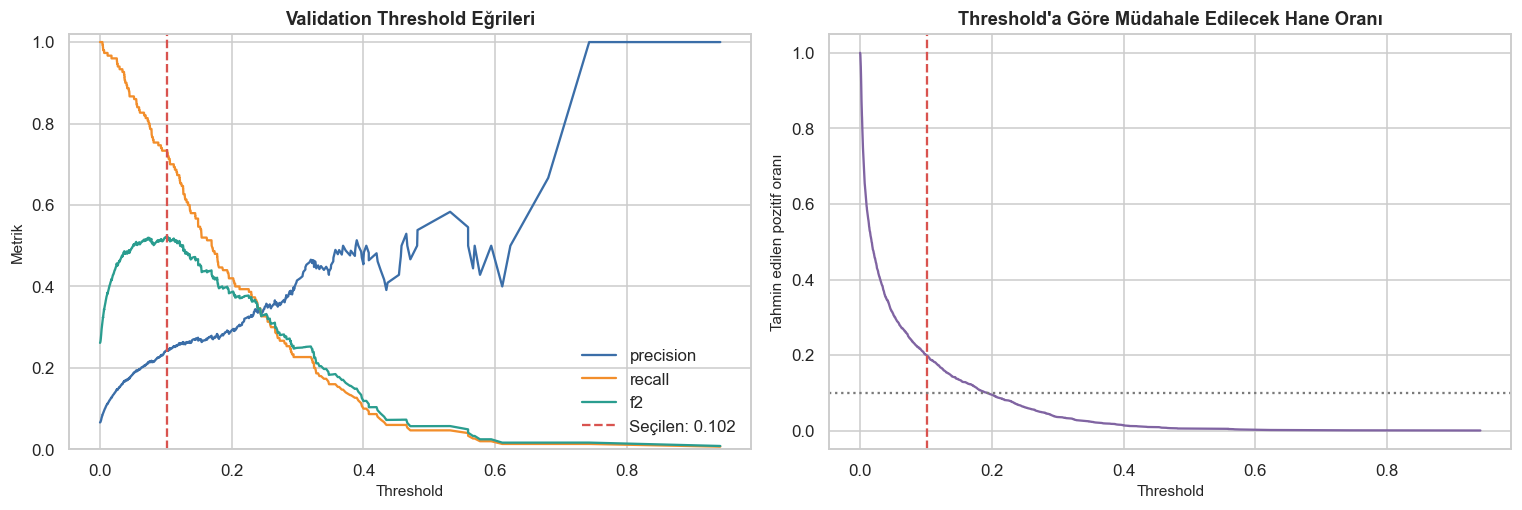

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

plot_thresholds = validation_threshold_table.sort_values("threshold")
for metric, color in [
    ("precision", COLORS["blue"]),
    ("recall", COLORS["orange"]),
    ("f2", COLORS["green"]),
]:
    axes[0].plot(
        plot_thresholds["threshold"],
        plot_thresholds[metric],
        label=metric,
        color=color,
    )
axes[0].axvline(
    SELECTED_THRESHOLD,
    color=COLORS["red"],
    linestyle="--",
    label=f"Seçilen: {SELECTED_THRESHOLD:.3f}",
)
axes[0].set_title("Validation Threshold Eğrileri")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Metrik")
axes[0].set_ylim(0, 1.02)
axes[0].legend()

axes[1].plot(
    plot_thresholds["threshold"],
    plot_thresholds["predicted_positive_rate"],
    color=COLORS["purple"],
)
axes[1].axvline(SELECTED_THRESHOLD, color=COLORS["red"], linestyle="--")
axes[1].axhline(TOP_K_RATE, color=COLORS["gray"], linestyle=":")
axes[1].set_title("Threshold'a Göre Müdahale Edilecek Hane Oranı")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Tahmin edilen pozitif oranı")

plt.tight_layout()
plt.show()

### Threshold ile top-k aynı karar değildir

- **F2 threshold:** Olasılığı eşikten büyük bütün haneleri pozitif sınıflandırır.
- **Top-k:** Operasyon kapasitesi ne olursa olsun tam olarak en riskli `%k` haneyi
  seçer.

Bu notebook F2 threshold'u sınıflandırma ve confusion matrix için; top-%10'u ise
sabit kampanya kapasitesi senaryosu için raporlar. İşletmenin gerçek iletişim
bütçesi farklıysa yalnızca `TOP_K_RATE` değiştirilmelidir. Test sonucuna bakarak
threshold veya kapasite değiştirilmemelidir.

Threshold değeri kalibre olasılık ölçeğindedir. Buna karşılık F2 hâlâ validation
üzerinde optimize edildiği için “doğal doğruluk sınırı 0.50 olmalıdır” varsayımı
yoktur. İş maliyeti değişirse threshold yalnızca yeni validation döneminde yeniden
seçilmelidir.

## 12. Validation confusion matrix ve hata yapısı

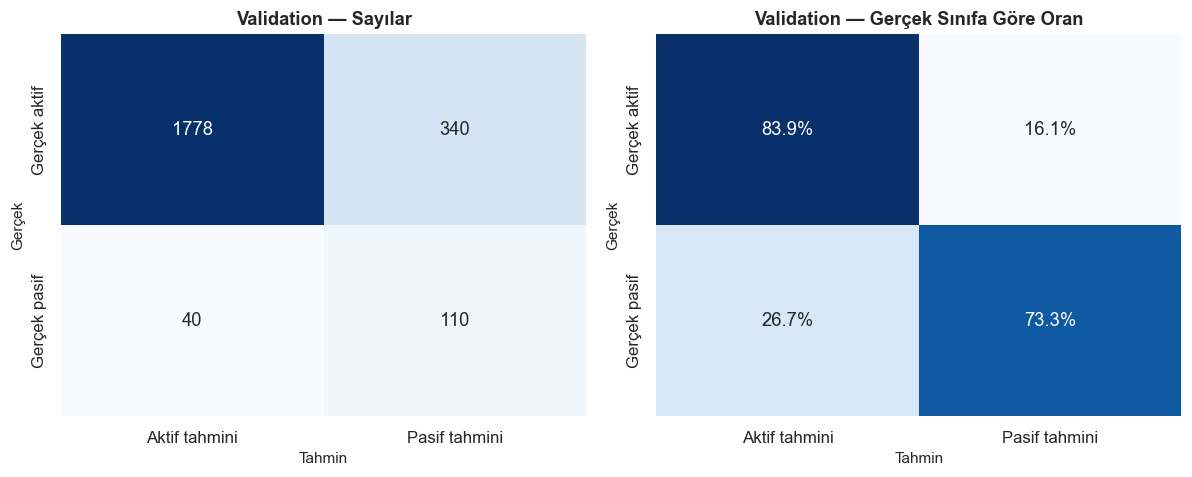

In [16]:
validation_confusion_counts, validation_confusion_rates = confusion_tables(
    y_validation,
    SELECTED_VALIDATION_PROBABILITY,
    SELECTED_THRESHOLD,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, matrix, title, fmt in [
    (axes[0], validation_confusion_counts, "Validation — Sayılar", "d"),
    (axes[1], validation_confusion_rates, "Validation — Gerçek Sınıfa Göre Oran", ".1%"),
]:
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        cbar=False,
        xticklabels=["Aktif tahmini", "Pasif tahmini"],
        yticklabels=["Gerçek aktif", "Gerçek pasif"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")

plt.tight_layout()
plt.show()

### Confusion matrix nasıl yorumlanmalı?

Bu problemde `false negative`, gerçekten pasif olacak bir hanenin riskli
işaretlenmemesidir. F2 bu hatayı azaltmaya ağırlık verir. Buna karşılık çok düşük
threshold fazla `false positive` üretir ve kampanya maliyetini artırır. Nihai
karar yalnızca F2'ye değil, müdahale kapasitesine ve yanlış alarm maliyetine de
bağlanmalıdır.

## 13. Test snapshot'ında tek seferlik nihai değerlendirme

> **Test kapısı:** Bu bölüm çalıştırılmadan önce model adı, feature seti,
> hiperparametreler, F2 threshold ve `TOP_K_RATE` validation sonuçlarıyla
> dondurulmuş olmalıdır. Aşağıdaki test sonucuna göre yukarıdaki seçimler
> değiştirilirse test artık gerçek holdout olmaktan çıkar.

**Sürüm geçmişi notu:** 655. gün test sonuçları önceki koşularda zaten görüldü.
Bu sürümün seçim kodu train/validation ile sınırlı kalsa da yeniden çalıştırılan
655. gün sonuçları artık hiç görülmemiş bağımsız son test diye sunulamaz.
Revize deneyin retrospektif kontrolü olarak raporlanır; güçlü bağımsız doğrulama
için daha önce incelenmemiş ve hedef penceresi tamamlanmış ileri bir snapshot
gerekir. Mevcut split burada değiştirilmez.

In [17]:
y_test = test_data[TARGET_COLUMN].astype(int)
TEST_RAW_SCORE = SELECTED_MODEL.predict_proba(
    test_data[SELECTED_FEATURES]
)[:, 1]

if SELECTED_PROBABILITY_METHOD == "platt_oof":
    TEST_PROBABILITY = apply_probability_calibrator(
        SELECTED_PROBABILITY_CALIBRATOR,
        TEST_RAW_SCORE,
    )
elif SELECTED_PROBABILITY_METHOD == "native_raw":
    TEST_PROBABILITY = TEST_RAW_SCORE.copy()
else:
    raise ValueError(
        f"Bilinmeyen olasılık yöntemi: {SELECTED_PROBABILITY_METHOD}"
    )

test_point_metrics = threshold_metrics(
    y_test,
    TEST_PROBABILITY,
    SELECTED_THRESHOLD,
)
# Only the frozen probability method is assessed on test; no test reselection.
test_ece_quantile, test_calibration_bins = quantile_calibration_summary(
    y_test, TEST_PROBABILITY
)
test_calibration_bins.insert(0, "score_name", SELECTED_PROBABILITY_METHOD)
test_point_metrics["ece_quantile"] = test_ece_quantile
# A constant baseline must use the TRAIN prior, not the test prevalence.
test_dummy_prior_probability = np.full(len(y_test), float(y_train.mean()))
test_point_metrics["dummy_prior_brier_score"] = float(
    brier_score_loss(y_test, test_dummy_prior_probability)
)
test_point_metrics_table = pd.Series(test_point_metrics).to_frame("test_value")
display(test_point_metrics_table)

test_prediction = (TEST_PROBABILITY >= SELECTED_THRESHOLD).astype("int8")
# Operasyonel sıra temel model skorundan üretilir. Seçilen olasılık yöntemi
# monoton olduğunda aynı sıra elde edilir; bu kullanım sözleşmeyi açık tutar.
ranking_order = np.argsort(-TEST_RAW_SCORE, kind="mergesort")
risk_rank = np.empty(len(test_data), dtype=int)
risk_rank[ranking_order] = np.arange(1, len(test_data) + 1)
top_k_count_test = max(1, math.ceil(len(test_data) * TOP_K_RATE))

prediction_columns = [
    "household_key", "snapshot_day", "observation_start_day",
    "prediction_start_day", "prediction_end_day", TARGET_COLUMN,
]
test_predictions = test_data[prediction_columns].copy()
test_predictions["raw_model_score"] = TEST_RAW_SCORE
test_predictions["probability_method"] = SELECTED_PROBABILITY_METHOD
test_predictions["lapse_probability"] = np.where(
    CALIBRATION_READY_FOR_DOWNSTREAM,
    TEST_PROBABILITY,
    np.nan,
)
test_predictions["probability_ready_for_downstream"] = (
    CALIBRATION_READY_FOR_DOWNSTREAM
)
test_predictions["predicted_inactive"] = test_prediction
test_predictions["risk_rank"] = risk_rank
test_predictions["risk_percentile"] = (
    1 - (test_predictions["risk_rank"] - 1) / len(test_predictions)
)
test_predictions["selected_top_k"] = (
    test_predictions["risk_rank"].le(top_k_count_test).astype("int8")
)

print(f"Seçilen olasılık yöntemi: {SELECTED_PROBABILITY_METHOD}")
print(f"Testte top-%{TOP_K_RATE * 100:.0f} hane sayısı: {top_k_count_test}")
display(
    test_predictions.sort_values("risk_rank")
    .head(20)
)

,test_value
average_precision,0.2734
roc_auc,0.8512
brier_score,0.0584
positive_rate,0.0722
top_k_rate,0.1000
top_k_count,229.0000
positives_captured_at_top_k,72.0000
recall_at_top_k,0.4364
precision_at_top_k,0.3144
lift_at_top_k,4.3522


Seçilen olasılık yöntemi: native_raw
Testte top-%10 hane sayısı: 229


,household_key,snapshot_day,observation_start_day,prediction_start_day,prediction_end_day,target_inactive,raw_model_score,probability_method,lapse_probability,probability_ready_for_downstream,predicted_inactive,risk_rank,risk_percentile,selected_top_k
10078,1108,655,474,656,711,0,0.8292,native_raw,0.8292,True,1,1,1.0000,1
10014,1038,655,474,656,711,0,0.6597,native_raw,0.6597,True,1,2,0.9996,1
10601,1682,655,474,656,711,0,0.6401,native_raw,0.6401,True,1,3,0.9991,1
9869,880,655,474,656,711,0,0.5914,native_raw,0.5914,True,1,4,0.9987,1
11041,2151,655,474,656,711,0,0.5909,native_raw,0.5909,True,1,5,0.9982,1
10969,2073,655,474,656,711,1,0.5789,native_raw,0.5789,True,1,6,0.9978,1
11054,2167,655,474,656,711,0,0.5557,native_raw,0.5557,True,1,7,0.9974,1
9662,657,655,474,656,711,0,0.5497,native_raw,0.5497,True,1,8,0.9969,1
11350,2495,655,474,656,711,1,0.5470,native_raw,0.5470,True,1,9,0.9965,1
10405,1466,655,474,656,711,0,0.5405,native_raw,0.5405,True,1,10,0.9961,1


### Test tablosu ne sağlar?

Her hane için ham model skoru, validation'da seçilip dondurulmuş yöntemle üretilen
pasiflik olasılığı, threshold kararı, risk sırası ve top-k seçimi saklanır.

- `raw_model_score` model denetimi, SHAP bağlantısı ve sıralama içindir.
- `probability_method`, testte `native_raw` mı yoksa `platt_oof` mu
  kullanıldığını görünür kılar.
- `lapse_probability` yalnızca `probability_ready_for_downstream=True` ise
  doldurulur ve Customer 360/chatbot tarafından olasılık cümlesinde kullanılabilir.
- `risk_rank`, `risk_percentile` ve `selected_top_k` operasyonel önceliklendirme
  alanlarıdır.

Test sonucu görüldükten sonra olasılık yöntemi, model, feature seti veya threshold
değiştirilmez. Yeni bir karar gerekiyorsa ileri bir snapshot yeni holdout olarak
ayrılmalıdır.

## 14. Test metrikleri için bootstrap güven aralıkları

In [18]:
def bootstrap_metric_intervals(
    y_true,
    probability,
    threshold,
    repetitions=BOOTSTRAP_REPETITIONS,
    confidence_level=BOOTSTRAP_CONFIDENCE_LEVEL,
    top_k_rate=TOP_K_RATE,
    random_state=RANDOM_STATE,
):
    y_true = np.asarray(y_true, dtype=int)
    probability = np.asarray(probability, dtype=float)
    rng = np.random.default_rng(random_state)
    metric_names = [
        "average_precision", "brier_score", "precision", "recall", "f2",
        "recall_at_top_k", "precision_at_top_k", "lift_at_top_k",
    ]
    bootstrap_records = []

    for bootstrap_id in range(repetitions):
        sampled_indices = rng.integers(0, len(y_true), size=len(y_true))
        sampled_y = y_true[sampled_indices]
        sampled_probability = probability[sampled_indices]
        if np.unique(sampled_y).size < 2:
            continue
        sampled_metrics = threshold_metrics(
            sampled_y,
            sampled_probability,
            threshold,
            top_k_rate,
        )
        bootstrap_records.append({
            "bootstrap_id": bootstrap_id,
            **{name: sampled_metrics[name] for name in metric_names},
        })

    bootstrap_distribution = pd.DataFrame(bootstrap_records)
    alpha = 1 - confidence_level
    point_metrics = threshold_metrics(
        y_true,
        probability,
        threshold,
        top_k_rate,
    )
    interval_records = []
    for metric_name in metric_names:
        values = bootstrap_distribution[metric_name].dropna()
        interval_records.append({
            "metric": metric_name,
            "point_estimate": point_metrics[metric_name],
            "ci_lower": values.quantile(alpha / 2),
            "ci_upper": values.quantile(1 - alpha / 2),
            "confidence_level": confidence_level,
            "successful_repetitions": len(values),
        })
    return pd.DataFrame(interval_records), bootstrap_distribution


test_bootstrap_intervals, test_bootstrap_distribution = (
    bootstrap_metric_intervals(
        y_test,
        TEST_PROBABILITY,
        SELECTED_THRESHOLD,
    )
)
display(test_bootstrap_intervals)

,metric,point_estimate,ci_lower,ci_upper,confidence_level,successful_repetitions
0,average_precision,0.2734,0.2271,0.3375,0.9500,1000
1,brier_score,0.0584,0.0512,0.0657,0.9500,1000
2,precision,0.2589,0.2185,0.2974,0.9500,1000
3,recall,0.7030,0.6358,0.7688,0.9500,1000
4,f2,0.5235,0.4687,0.5746,0.9500,1000
5,recall_at_top_k,0.4364,0.3714,0.5092,0.9500,1000
6,precision_at_top_k,0.3144,0.2576,0.3755,0.9500,1000
7,lift_at_top_k,4.3522,3.7045,5.0787,0.9500,1000


### Güven aralığının sınırı

Bootstrap, validation'da seçilip dondurulmuş yöntemle üretilen test olasılıklarını
ve aynı test snapshot'ındaki haneleri tekrar örnekleyerek **test örneklem
belirsizliğini** ölçer. Modelin yeniden eğitilmesinden, hiperparametre seçiminden
ve farklı takvim dönemlerinden kaynaklanan bütün belirsizliği kapsamaz.

Test snapshot'ında her hane tek satır olduğu için örnekleme birimi hane satırıdır.
Her tekrarda top-k sıralaması yeniden hesaplanır. Sonuçlar `nokta tahmini
(%95 alt sınır, %95 üst sınır)` biçiminde raporlanmalıdır.

## 15. PR eğrisi, kalibrasyon ve hedefleme kapasitesi

,score_name,bin_id,lower_edge,upper_edge,rows,positive_rows,weight,mean_probability,observed_positive_rate,absolute_gap,weighted_gap
0,native_raw,1,0.0001,0.0020,229,0,0.1003,0.0013,0.0000,0.0013,0.0001
1,native_raw,2,0.0020,0.0034,228,1,0.0998,0.0026,0.0044,0.0018,0.0002
2,native_raw,3,0.0034,0.0057,228,2,0.0998,0.0046,0.0088,0.0042,0.0004
3,native_raw,4,0.0057,0.0101,229,2,0.1003,0.0076,0.0087,0.0011,0.0001
4,native_raw,5,0.0101,0.0185,228,7,0.0998,0.0134,0.0307,0.0173,0.0017
5,native_raw,6,0.0185,0.0320,228,7,0.0998,0.0244,0.0307,0.0063,0.0006
6,native_raw,7,0.0320,0.0573,229,14,0.1003,0.0438,0.0611,0.0173,0.0017
7,native_raw,8,0.0573,0.0997,228,16,0.0998,0.0767,0.0702,0.0066,0.0007
8,native_raw,9,0.0997,0.1971,228,44,0.0998,0.1426,0.1930,0.0503,0.0050
9,native_raw,10,0.1971,0.8292,229,72,0.1003,0.3260,0.3144,0.0116,0.0012


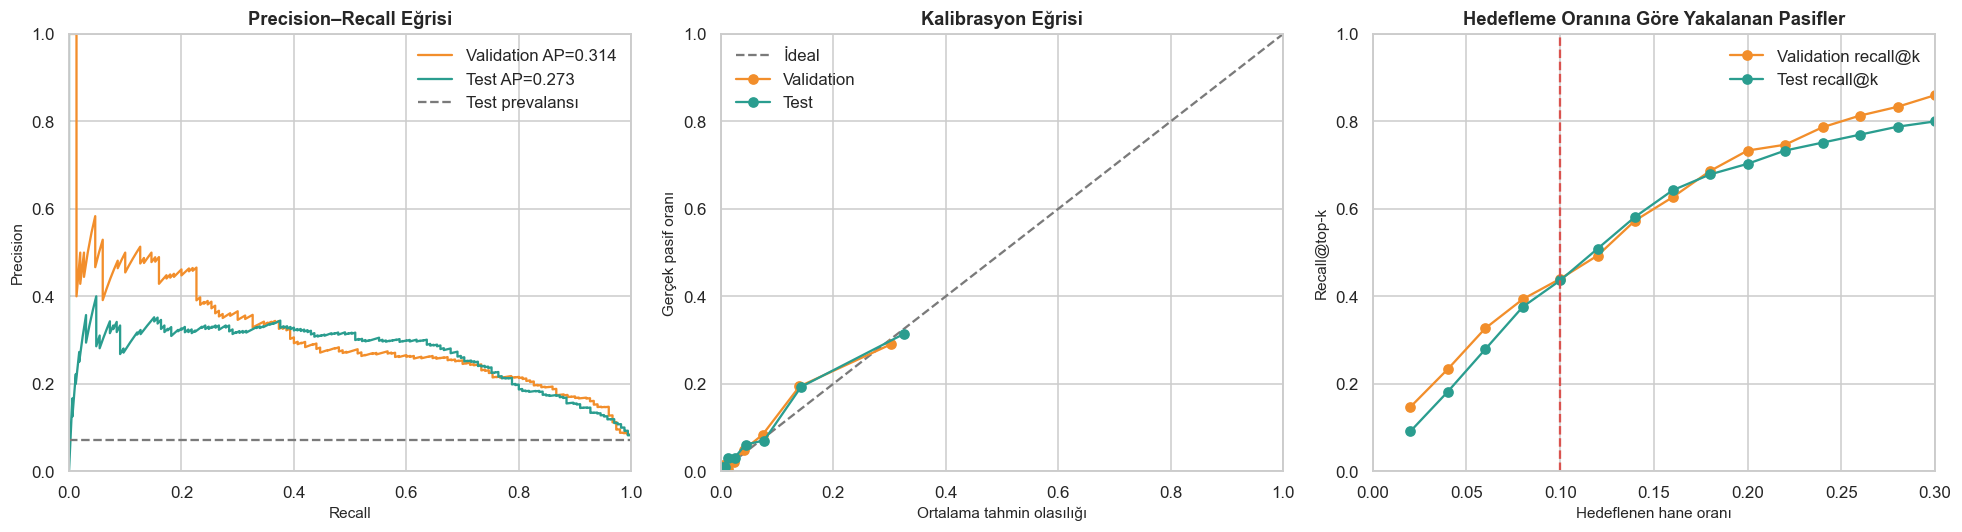

In [19]:
def targeting_curve(y_true, probability, rates):
    records = []
    for rate in rates:
        records.append({"rate": rate, **top_k_metrics(y_true, probability, rate)})
    return pd.DataFrame(records)


validation_precision, validation_recall, _ = precision_recall_curve(
    y_validation,
    SELECTED_VALIDATION_PROBABILITY,
)
test_precision, test_recall, _ = precision_recall_curve(
    y_test,
    TEST_PROBABILITY,
)

selected_validation_bins = validation_calibration_bins.loc[
    validation_calibration_bins["score_name"].eq(SELECTED_PROBABILITY_METHOD)
]
validation_fraction_positive = selected_validation_bins["observed_positive_rate"]
validation_mean_probability = selected_validation_bins["mean_probability"]
test_fraction_positive = test_calibration_bins["observed_positive_rate"]
test_mean_probability = test_calibration_bins["mean_probability"]
display(test_calibration_bins)

targeting_rates = np.arange(0.02, 0.32, 0.02)
validation_targeting = targeting_curve(
    y_validation,
    SELECTED_VALIDATION_PROBABILITY,
    targeting_rates,
)
test_targeting = targeting_curve(
    y_test,
    TEST_PROBABILITY,
    targeting_rates,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(
    validation_recall,
    validation_precision,
    color=COLORS["orange"],
    label=f"Validation AP={average_precision_score(y_validation, SELECTED_VALIDATION_PROBABILITY):.3f}",
)
axes[0].plot(
    test_recall,
    test_precision,
    color=COLORS["green"],
    label=f"Test AP={average_precision_score(y_test, TEST_PROBABILITY):.3f}",
)
axes[0].axhline(y_test.mean(), color=COLORS["gray"], linestyle="--", label="Test prevalansı")
axes[0].set_title("Precision–Recall Eğrisi")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].plot([0, 1], [0, 1], color=COLORS["gray"], linestyle="--", label="İdeal")
axes[1].plot(
    validation_mean_probability,
    validation_fraction_positive,
    marker="o",
    color=COLORS["orange"],
    label="Validation",
)
axes[1].plot(
    test_mean_probability,
    test_fraction_positive,
    marker="o",
    color=COLORS["green"],
    label="Test",
)
axes[1].set_title("Kalibrasyon Eğrisi")
axes[1].set_xlabel("Ortalama tahmin olasılığı")
axes[1].set_ylabel("Gerçek pasif oranı")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()

axes[2].plot(
    validation_targeting["rate"],
    validation_targeting["recall_at_top_k"],
    marker="o",
    color=COLORS["orange"],
    label="Validation recall@k",
)
axes[2].plot(
    test_targeting["rate"],
    test_targeting["recall_at_top_k"],
    marker="o",
    color=COLORS["green"],
    label="Test recall@k",
)
axes[2].axvline(TOP_K_RATE, color=COLORS["red"], linestyle="--")
axes[2].set_title("Hedefleme Oranına Göre Yakalanan Pasifler")
axes[2].set_xlabel("Hedeflenen hane oranı")
axes[2].set_ylabel("Recall@top-k")
axes[2].set_xlim(0, targeting_rates.max())
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()

### Grafiklerden hangi kararlar çıkarılır?

- PR eğrisi validation ve testte benzer biçimdeyse sıralama daha kararlıdır.
- Kalibrasyon eğrisi validation'da seçilen son olasılık yöntemini gösterir.
  Noktaların diyagonale yaklaşması, `lapse_probability` alanının frekans olarak
  daha güvenilir olduğunu gösterir.
- Hedefleme eğrisi, kampanya kapasitesi arttıkça yakalanan pasif hane oranının
  nasıl değiştiğini gösterir.

Test kalibrasyonu validation'a göre kötü çıktığında test üzerinde yöntem veya
kalibratör yeniden seçilmez. Sonraki sürümde daha ileri tarihli ayrı bir
kalibrasyon dönemi kullanılmalı ve drift izleme kuralı tanımlanmalıdır; mevcut
test snapshot'ı yeni ayarları seçmek için geri beslenmemelidir.

Dummy Brier karşılaştırmasında aynı split kullanılmalıdır: önceki tabloda görülen
yaklaşık 0.062 validation referansıdır, test referansı değildir. Bu sürüm test
dummy Brier'ını train prevalansına sabitlenen tahminle ayrıca hesaplar. Test ECE
de yalnızca dondurulmuş yöntemin tanısal değerlendirmesidir; seçime geri beslenmez.

## 16. Global açıklanabilirlik: permutation importance

,feature,importance_mean,importance_std
0,active_weeks,0.0940,0.0239
1,recent_mean_purchase_gap_3,0.0575,0.0137
2,unique_products,0.0185,0.0142
3,weekly_spend_cv_12w,0.0175,0.0064
4,basket_slope_12w,0.0117,0.0107
5,discounted_basket_rate,0.0092,0.0035
6,active_weeks_last_4w,0.0091,0.0084
7,customer_spend_last_4w,0.0089,0.0073
8,spend_slope_12w,0.0057,0.0093
9,customer_spend_total,0.0044,0.0087


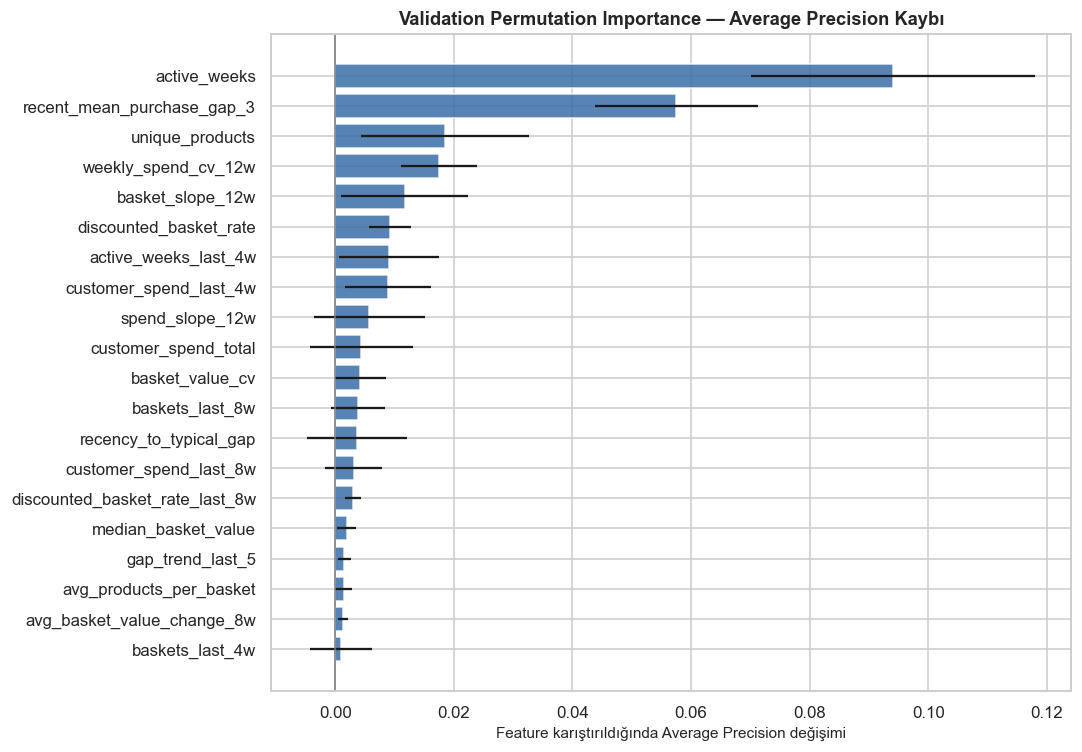

In [20]:
permutation_result = permutation_importance(
    SELECTED_MODEL,
    validation_data[SELECTED_FEATURES],
    y_validation,
    scoring="average_precision",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

selected_feature_importance = (
    pd.DataFrame({
        "feature": SELECTED_FEATURES,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(selected_feature_importance.head(25))

plot_importance = selected_feature_importance.head(20).sort_values(
    "importance_mean"
)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    plot_importance["feature"],
    plot_importance["importance_mean"],
    xerr=plot_importance["importance_std"],
    color=COLORS["blue"],
    alpha=0.85,
)
ax.axvline(0, color=COLORS["gray"], linewidth=1)
ax.set_title("Validation Permutation Importance — Average Precision Kaybı")
ax.set_xlabel("Feature karıştırıldığında Average Precision değişimi")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Permutation importance nasıl yorumlanmalı?

Bir feature validation'da karıştırıldığında Average Precision belirgin düşüyorsa
model o feature'ın taşıdığı bilgiden yararlanıyordur. Korelasyonlu feature'lar
birbirinin yerini alabildiği için her birinin tekil önemi düşük görünebilir.
Negatif veya sıfıra yakın önem, feature'ın kesinlikle gereksiz olduğunu tek başına
kanıtlamaz.

Bu analiz nedensellik göstermez; örneğin yüksek recency'nin önemli olması,
recency'yi doğrudan değiştirmenin müşteriyi aktif yapacağını kanıtlamaz.

## 17. Yerel açıklamalar: SHAP

SHAP opsiyonel bir bağımlılıktır. `import shap` hatası alınırsa notebook ile
aynı kernel ortamında yeni bir hücrede bir kez aşağıdaki komut çalıştırılır:

```python
%pip install -U shap
```

Kurulum bittikten sonra **Kernel → Restart Kernel and Run All Cells** seçilir.
Notebook paket kurulumunu otomatik yapmaz; böylece analiz çalışırken ortamın
habersizce değişmesi engellenir. SHAP kurulamazsa akış durmaz ve global
`permutation_importance` çıktısı yine üretilir.

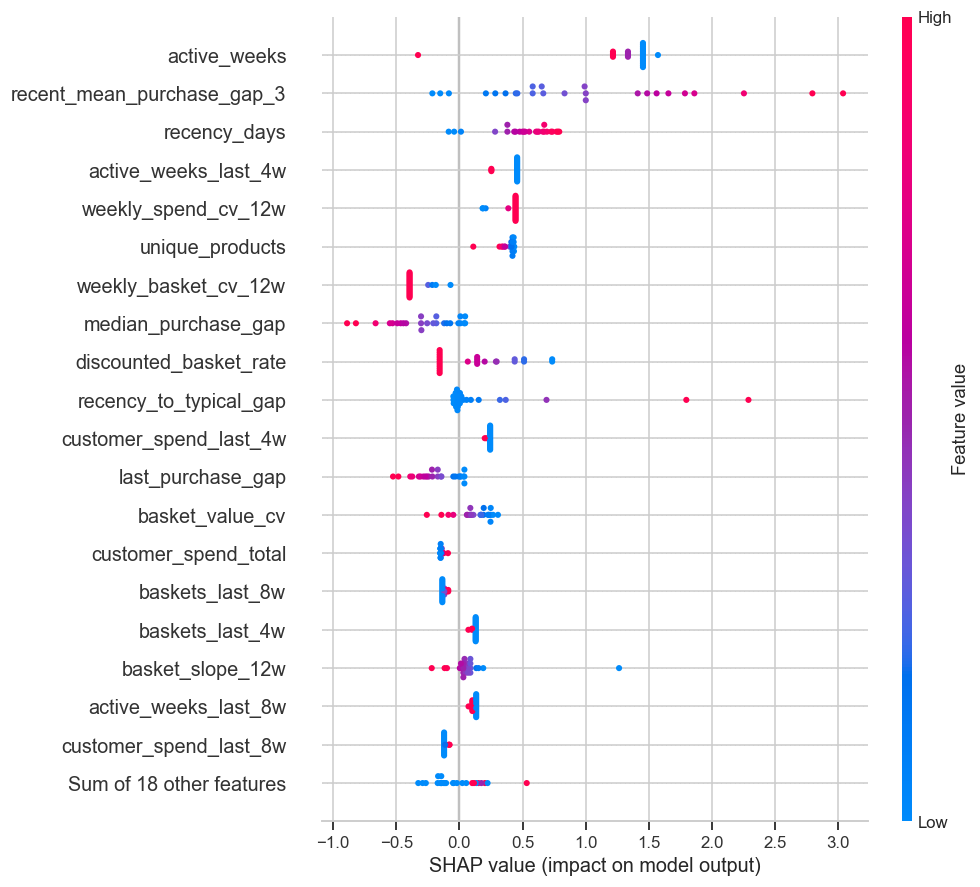

,household_key,snapshot_day,raw_model_score,probability_method,lapse_probability,driver_rank,raw_feature,raw_feature_value,transformed_feature,transformed_value,shap_contribution_model_output,direction_sign,shap_output_scale,probability_ready_for_downstream,direction
0,1108,655,0.8292,native_raw,0.8292,1,recency_to_typical_gap,45.0000,recency_to_typical_gap,14.7381,1.7969,1,log_odds,True,riski artıran
1,1108,655,0.8292,native_raw,0.8292,2,active_weeks,1.0000,active_weeks,-1.9140,1.5723,1,log_odds,True,riski artıran
2,1108,655,0.8292,native_raw,0.8292,3,discounted_basket_rate,0.0000,discounted_basket_rate,-6.0174,0.7347,1,log_odds,True,riski artıran
3,1108,655,0.8292,native_raw,0.8292,4,active_weeks_last_4w,0.0000,active_weeks_last_4w,-1.7331,0.4572,1,log_odds,True,riski artıran
4,1108,655,0.8292,native_raw,0.8292,5,weekly_spend_cv_12w,3.4641,weekly_spend_cv_12w,2.4499,0.4446,1,log_odds,True,riski artıran
5,1038,655,0.6597,native_raw,0.6597,1,recency_to_typical_gap,57.0000,recency_to_typical_gap,18.8030,2.2890,1,log_odds,True,riski artıran
6,1038,655,0.6597,native_raw,0.6597,2,basket_slope_12w,-0.4825,basket_slope_12w,-3.8887,1.2643,1,log_odds,True,riski artıran
7,1038,655,0.6597,native_raw,0.6597,3,recency_days,57.0000,recency_days,2.9526,0.5096,1,log_odds,True,riski artıran
8,1038,655,0.6597,native_raw,0.6597,4,active_weeks_last_4w,0.0000,active_weeks_last_4w,-1.7331,0.4572,1,log_odds,True,riski artıran
9,1038,655,0.6597,native_raw,0.6597,5,active_weeks,17.0000,active_weeks,0.2578,-0.3278,-1,log_odds,True,riski azaltan


In [21]:
SHAP_EXPLANATION_ROWS = 25
SHAP_TOP_DRIVERS_PER_HOUSEHOLD = 5
shap_local_drivers = None
shap_error = None


def infer_raw_feature_name(transformed_feature, raw_feature_names):
    transformed_feature = str(transformed_feature)
    without_transformer_prefix = transformed_feature.split("__", 1)[-1]
    if without_transformer_prefix in raw_feature_names:
        return without_transformer_prefix

    prefix_matches = [
        feature for feature in raw_feature_names
        if without_transformer_prefix.startswith(f"{feature}_")
    ]
    if prefix_matches:
        return max(prefix_matches, key=len)
    return None


try:
    import shap

    selected_preprocessor = SELECTED_MODEL.named_steps["preprocessor"]
    selected_estimator = SELECTED_MODEL.named_steps["model"]

    background_raw = train_data[SELECTED_FEATURES].sample(
        n=min(200, len(train_data)),
        random_state=RANDOM_STATE,
    )
    high_risk_positions = np.argsort(
        -TEST_RAW_SCORE,
        kind="mergesort",
    )[:SHAP_EXPLANATION_ROWS]
    explanation_raw = test_data.iloc[
        high_risk_positions
    ][SELECTED_FEATURES].copy()

    background_transformed = selected_preprocessor.transform(background_raw)
    explanation_transformed = selected_preprocessor.transform(explanation_raw)
    if sparse.issparse(background_transformed):
        background_transformed = background_transformed.toarray()
    if sparse.issparse(explanation_transformed):
        explanation_transformed = explanation_transformed.toarray()

    transformed_feature_names = selected_preprocessor.get_feature_names_out()
    explainer = shap.Explainer(
        selected_estimator,
        background_transformed,
        feature_names=transformed_feature_names,
    )
    shap_explanation = explainer(explanation_transformed)
    if np.asarray(shap_explanation.values).ndim == 3:
        shap_explanation = shap_explanation[:, :, 1]

    shap.plots.beeswarm(shap_explanation, max_display=20)

    local_driver_records = []
    for row_position, test_position in enumerate(high_risk_positions):
        contributions = np.asarray(shap_explanation.values[row_position])
        top_positions = np.argsort(-np.abs(contributions))[
            :SHAP_TOP_DRIVERS_PER_HOUSEHOLD
        ]
        for driver_rank, feature_position in enumerate(top_positions, start=1):
            contribution = float(contributions[feature_position])
            transformed_feature = str(
                transformed_feature_names[feature_position]
            )
            raw_feature = infer_raw_feature_name(
                transformed_feature,
                SELECTED_FEATURES,
            )
            raw_feature_value = (
                explanation_raw.iloc[row_position][raw_feature]
                if raw_feature is not None
                else np.nan
            )
            if isinstance(raw_feature_value, np.generic):
                raw_feature_value = raw_feature_value.item()

            local_driver_records.append({
                "household_key": test_data.iloc[test_position]["household_key"],
                "snapshot_day": int(test_data.iloc[test_position]["snapshot_day"]),
                "raw_model_score": float(TEST_RAW_SCORE[test_position]),
                "probability_method": SELECTED_PROBABILITY_METHOD,
                "lapse_probability": (
                    float(TEST_PROBABILITY[test_position])
                    if CALIBRATION_READY_FOR_DOWNSTREAM
                    else np.nan
                ),
                "driver_rank": driver_rank,
                "raw_feature": raw_feature,
                "raw_feature_value": raw_feature_value,
                "transformed_feature": transformed_feature,
                "transformed_value": float(
                    explanation_transformed[row_position, feature_position]
                ),
                "shap_contribution_model_output": contribution,
                "direction_sign": int(np.sign(contribution)),
                "shap_output_scale": (
                    "log_odds" if SELECTED_FAMILY == "logistic"
                    else "base_model_positive_probability"
                ),
                "probability_ready_for_downstream": CALIBRATION_READY_FOR_DOWNSTREAM,
                "direction": (
                    "riski artıran" if contribution > 0
                    else "riski azaltan" if contribution < 0
                    else "nötr"
                ),
            })
    shap_local_drivers = pd.DataFrame(local_driver_records)
    display(shap_local_drivers.head(20))

except ImportError:
    shap_error = "shap paketi kurulu değil; permutation importance çıktısı kullanılacak."
    print(shap_error)
except Exception as error:
    shap_error = f"SHAP bu ortamda üretilemedi: {type(error).__name__}: {error}"
    print(shap_error)

### SHAP çıktısının kullanım sınırı

SHAP seçilen **temel modelin** çıktısını açıklar; daha sonra seçilen olasılık
yöntemini nedensel bir model gibi yorumlamaz. `native_raw` kimlik dönüşümüdür;
`platt_oof` ise monoton artan olduğundan katkıların riski artıran/azaltan yönünü
korur. SHAP katkısının sayısal büyüklüğü doğrudan olasılık puanı değildir.

`transformed_value`, model pipeline'ına giren standartlaştırılmış veya one-hot
değer olabilir. Customer 360 ve chatbot açıklamasında bunun yerine yeni eklenen
`raw_feature` ve `raw_feature_value` alanları kullanılmalıdır. Böylece örneğin
standartlaştırılmış `2.95` değeri yanlışlıkla “2.95 gün” diye sunulmaz.

En yüksek riskli 25 hane için seçilen olasılık, ham özellik değeri ve riski
artıran/azaltan ilk beş katkı kaydedilir. Bu değerler “özelliği değiştirirsek
müşteri kesin kalır” anlamına gelmez; modelin tahminini hangi gözlenen davranışla
ilişkilendirdiğini gösterir. Chatbot nedensel tavsiye üretmemelidir.

Çok dilli tüketiciler Türkçe `direction` metnini ayrıştırmaz; `direction_sign`
alanını kullanır (`+1`: artıran, `-1`: azaltan, `0`: nötr). `shap_output_scale`
katkının birimini belirtir; Logistic için log-odds katkısıdır. Bunlar son
olasılığa eklenebilecek yüzde puanlar değildir.

## 18. Demografi kaydı bulunurluğuna göre sağlamlık kontrolü

In [22]:
demographic_group_records = []

if "has_demographic" in model_panel.columns:
    for split_name, frame, probability in [
        ("validation", validation_data, SELECTED_VALIDATION_PROBABILITY),
        ("test", test_data, TEST_PROBABILITY),
    ]:
        working = frame[[TARGET_COLUMN, "has_demographic"]].copy()
        working["probability"] = probability
        for group_value, group in working.groupby("has_demographic", dropna=False):
            if group[TARGET_COLUMN].nunique() < 2:
                average_precision = np.nan
                roc_auc = np.nan
            else:
                average_precision = average_precision_score(
                    group[TARGET_COLUMN], group["probability"]
                )
                roc_auc = roc_auc_score(
                    group[TARGET_COLUMN], group["probability"]
                )
            prediction = group["probability"].ge(SELECTED_THRESHOLD).astype(int)
            demographic_group_records.append({
                "split": split_name,
                "has_demographic": group_value,
                "rows": len(group),
                "positive_rows": int(group[TARGET_COLUMN].sum()),
                "sample_size_reliable": bool(
                    group[TARGET_COLUMN].sum() >= MIN_SUBGROUP_POSITIVES
                ),
                "positive_rate": float(group[TARGET_COLUMN].mean()),
                "average_precision": average_precision,
                "roc_auc": roc_auc,
                "selection_rate": float(prediction.mean()),
                "precision": precision_score(
                    group[TARGET_COLUMN], prediction, zero_division=0
                ),
                "recall": recall_score(
                    group[TARGET_COLUMN], prediction, zero_division=0
                ),
            })

demographic_group_metrics = pd.DataFrame(demographic_group_records)
if not demographic_group_metrics.empty:
    demographic_group_metrics = demographic_group_metrics.sort_values(
        ["sample_size_reliable", "split", "positive_rows"],
        ascending=[False, True, False],
    ).reset_index(drop=True)
    print(f"Alt grup raporlama eşiği: en az {MIN_SUBGROUP_POSITIVES} pozitif hane")
    display(demographic_group_metrics)
    if (~demographic_group_metrics["sample_size_reliable"]).any():
        print("DİKKAT: sample_size_reliable=False satırları betimseldir; "
              "kalıcı performans/fairness sonucu çıkarılmaz.")
else:
    print("has_demographic yok; alt grup analizi yapılmadı.")

Alt grup raporlama eşiği: en az 30 pozitif hane


,split,has_demographic,rows,positive_rows,sample_size_reliable,positive_rate,average_precision,roc_auc,selection_rate,precision,recall
0,test,0,1489,152,True,0.1021,0.2831,0.8121,0.2915,0.2581,0.7368
1,validation,0,1467,140,True,0.0954,0.3230,0.8157,0.2986,0.2397,0.7500
2,test,1,795,13,False,0.0164,0.1694,0.7907,0.0176,0.2857,0.3077
3,validation,1,801,10,False,0.0125,0.3251,0.9274,0.0150,0.4167,0.5000


DİKKAT: sample_size_reliable=False satırları betimseldir; kalıcı performans/fairness sonucu çıkarılmaz.


### Bu tablo fairness analizi değildir

`has_demographic=0`, hanenin belirli bir sosyal gruba ait olduğunu değil,
demografi kaydının bulunmadığını gösterir. Gruplar arasında recall farkı varsa
model demografi kaydı mevcut ve mevcut olmayan hanelerde farklı çalışıyor olabilir.

Ancak yorumdan önce mutlaka `positive_rows` sütununa bakılmalıdır. Örneğin bir
grupta yalnızca 10–15 pozitif satır varsa tek bir hanenin doğru/yanlış yakalanması
recall'ı yaklaşık 7–10 puan değiştirebilir. Böyle bir fark raporda sınırlılık
olarak belirtilir; fairness veya kalıcı performans farkı olarak genellenmez.
Fark yeni snapshot'larda ve daha büyük pozitif örneklemde tekrar gözlenirse ayrıca
incelenmelidir.

`sample_size_reliable = (positive_rows >= 30)` yalnızca recall yorumunu
sınırlandıran pratik bir raporlama işaretidir; 30 sayısı evrensel veya istatistiksel
bir güvenilirlik sınırı değildir. `True` olması anlamlı fark kanıtlamaz ve precision
paydasının yeterli olduğunu garanti etmez. `False` satırlar silinmez, betimsel
sonuçlar olarak saklanır. Önceki koşudaki 10 ve 13 pozitifli satırlar bu işaretle
otomatik olarak uyarılacaktır. Testteki farklara göre grup eşiği ayarlanmaz.

## 19. Model ve değerlendirme çıktılarının kaydedilmesi

### Aktif yöntem ile arşivlenmiş kalibratör farklıdır

Bundle'daki `probability_calibrator` yalnızca aktif Platt seçildiyse doludur.
`available_calibrator` ise train OOF ile öğrenilen Platt adayını **her koşulda**
denetim ve yeniden üretim amacıyla saklar. `native_raw` seçilince bu arşiv nesnesi
kendiliğinden kullanılmaz. `selected_probability_method` aktif seçimdir;
`probability_method` aynı değeri taşıyan geriye uyumlu alandır.

Drift varsa eski kalibratörün de geçerliliği değişmiş olabilir. Yeni etiketli,
ileri tarihli kalibrasyon/validation verisiyle tekrar değerlendirilmeli; olasılık
ölçeği değişirse threshold da yeniden doğrulanmalıdır. Bu nedenle
`auto_fallback_allowed=False`; saklamak, otomatik devreye alma izni değildir.

Sınıf ağırlığı denetimi, validation/test bin tabloları ve ECE özeti ayrıca
kaydedilir. Metadata'daki `class_weight_audit_finding` güncel CV tablosundan
türetilir; önceki çalıştırmanın sayıları sabit metin olarak kaydedilmez.

In [23]:
MODEL_BUNDLE_PATH = PROCESSED_PATH / "inactivity_risk_model_bundle.joblib"
TEST_PREDICTIONS_PATH = PROCESSED_PATH / "test_inactivity_risk_predictions.parquet"
INNER_CV_PATH = INTERIM_PATH / "model_inner_forward_cv.csv"
INNER_CV_SUMMARY_PATH = INTERIM_PATH / "model_inner_forward_cv_summary.csv"
VALIDATION_COMPARISON_PATH = INTERIM_PATH / "model_validation_comparison.csv"
CALIBRATION_OOF_PATH = INTERIM_PATH / "calibration_oof_predictions.csv"
CALIBRATION_COMPARISON_PATH = INTERIM_PATH / "calibration_validation_comparison.csv"
THRESHOLD_PATH = INTERIM_PATH / "validation_threshold_search.csv"
TEST_METRICS_PATH = INTERIM_PATH / "test_metrics.csv"
BOOTSTRAP_CI_PATH = INTERIM_PATH / "test_bootstrap_intervals.csv"
FEATURE_IMPORTANCE_PATH = INTERIM_PATH / "selected_feature_importance.csv"
DEMOGRAPHIC_GROUP_PATH = INTERIM_PATH / "demographic_availability_metrics.csv"
SHAP_LOCAL_PATH = INTERIM_PATH / "shap_local_drivers.csv"
MODELING_METADATA_PATH = INTERIM_PATH / "modeling_metadata.json"
CLASS_WEIGHT_AUDIT_PATH = INTERIM_PATH / "class_weight_audit.csv"
VALIDATION_CALIBRATION_BINS_PATH = INTERIM_PATH / "validation_calibration_bins.csv"
TEST_CALIBRATION_BINS_PATH = INTERIM_PATH / "test_calibration_bins.csv"

model_bundle = {
    "pipeline": SELECTED_MODEL,
    "probability_method": SELECTED_PROBABILITY_METHOD,
    "selected_probability_method": SELECTED_PROBABILITY_METHOD,
    "available_calibrator": PROBABILITY_CALIBRATOR,
    "available_calibrator_method": "platt_oof",
    "available_calibrator_input_transform": "logit(clipped raw positive-class probability)",
    "available_calibrator_role": "audit_and_revalidation_only",
    "auto_fallback_allowed": False,
    "probability_gate_scope": "validation_minimum_screen_not_calibration_guarantee",
    "probability_calibrator": SELECTED_PROBABILITY_CALIBRATOR,
    "calibration_input_transform": SELECTED_PROBABILITY_INPUT_TRANSFORM,
    "calibration_clip_epsilon": PROBABILITY_CLIP_EPSILON,
    "probability_ready_for_downstream": CALIBRATION_READY_FOR_DOWNSTREAM,
    "downstream_probability_field": "lapse_probability",
    "raw_score_field": "raw_model_score",
    "model_name": SELECTED_MODEL_NAME,
    "family": SELECTED_FAMILY,
    "feature_set": SELECTED_FEATURE_SET,
    "feature_names": SELECTED_FEATURES,
    "target_column": TARGET_COLUMN,
    "target_definition": target_design.get("target_definition"),
    "decision_threshold": SELECTED_THRESHOLD,
    "top_k_rate": TOP_K_RATE,
    "train_snapshot_days": split_days["train"],
    "validation_snapshot_days": split_days["validation"],
    "test_snapshot_days": split_days["test"],
}
joblib.dump(model_bundle, MODEL_BUNDLE_PATH)

test_predictions.to_parquet(TEST_PREDICTIONS_PATH, index=False)
class_weight_audit.to_csv(CLASS_WEIGHT_AUDIT_PATH, index=False)
validation_calibration_bins.to_csv(VALIDATION_CALIBRATION_BINS_PATH, index=False)
test_calibration_bins.to_csv(TEST_CALIBRATION_BINS_PATH, index=False)
inner_cv_results.to_csv(INNER_CV_PATH, index=False)
inner_cv_summary.to_csv(INNER_CV_SUMMARY_PATH, index=False)
validation_model_comparison.to_csv(VALIDATION_COMPARISON_PATH, index=False)
calibration_oof_predictions.to_csv(CALIBRATION_OOF_PATH, index=False)
calibration_validation_comparison.to_csv(
    CALIBRATION_COMPARISON_PATH, index=False
)
validation_threshold_table.to_csv(THRESHOLD_PATH, index=False)
test_point_metrics_table.reset_index(names="metric").to_csv(
    TEST_METRICS_PATH, index=False
)
test_bootstrap_intervals.to_csv(BOOTSTRAP_CI_PATH, index=False)
selected_feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
demographic_group_metrics.to_csv(DEMOGRAPHIC_GROUP_PATH, index=False)
if shap_local_drivers is not None:
    shap_local_drivers.to_csv(SHAP_LOCAL_PATH, index=False)


def to_native(value):
    if isinstance(value, dict):
        return {str(key): to_native(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_native(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


modeling_metadata = {
    "selected_model_name": SELECTED_MODEL_NAME,
    "selected_family": SELECTED_FAMILY,
    "selected_feature_set": SELECTED_FEATURE_SET,
    "selected_feature_count": len(SELECTED_FEATURES),
    "selected_hyperparameters": selected_hyperparameters[SELECTED_FAMILY],
    "class_weight_audit_finding": class_weight_audit_finding,
    "class_weight_audit": class_weight_audit.to_dict(orient="records"),
    "isotonic_decision": {
        "included": False,
        "reason": "ties_conflict_with_strict_score_order_preservation",
    },
    "subgroup_reporting": {
        "minimum_positive_rows": MIN_SUBGROUP_POSITIVES,
        "rule": "positive_rows >= minimum_positive_rows",
        "heuristic_not_significance_test": True,
    },
    "selection_metric": "validation average_precision",
    "threshold_selection_metric": "validation F2",
    "selected_threshold": SELECTED_THRESHOLD,
    "top_k_rate": TOP_K_RATE,
    "probability_contract": {
        "raw_score_field": "raw_model_score",
        "downstream_probability_field": "lapse_probability",
        "raw_score_must_not_be_presented_as_frequency": True,
        "selected_probability_method": SELECTED_PROBABILITY_METHOD,
        "method_selection_split": "validation",
        "available_calibrator_saved": True,
        "auto_fallback_allowed": False,
        "activation_requires_new_labeled_validation_and_threshold_review": True,
        "gate_scope": "minimum_validation_screen_not_calibration_guarantee",
        "platt_candidate_fit": "chronological train OOF scores",
        "calibration_clip_epsilon": PROBABILITY_CLIP_EPSILON,
        "calibration_snapshot_days": sorted(
            calibration_oof_predictions["snapshot_day"].unique().tolist()
        ),
        "platt_slope": float(PROBABILITY_CALIBRATOR.coef_[0, 0]),
        "platt_intercept": float(PROBABILITY_CALIBRATOR.intercept_[0]),
        "validation_raw_brier": raw_validation_brier,
        "validation_platt_brier": platt_validation_brier,
        "validation_selected_brier": selected_validation_brier,
        "validation_selected_mean_probability": selected_validation_mean_probability,
        "validation_dummy_brier": dummy_validation_brier,
        "rank_preserved": calibration_rank_preserved,
        "ready_for_downstream": CALIBRATION_READY_FOR_DOWNSTREAM,
    },
    "calibration_diagnostics": {
        "metric": "class_1_ECE_weighted_absolute_bin_gap",
        "strategy": "quantile_per_candidate",
        "requested_bins": CALIBRATION_N_BINS,
        "binning": "sklearn_calibration_curve_quantile_left_search_empty_bins_omitted",
        "validation_by_method": {
            row["score_name"]: {
                "ece_quantile": float(row["ece_quantile"]),
                "brier_score": float(row["brier_score"]),
                "effective_bins": int(row["effective_calibration_bins"]),
            }
            for row in calibration_validation_records
        },
        "test_selected_method": SELECTED_PROBABILITY_METHOD,
        "test_ece_quantile": test_ece_quantile,
        "test_effective_bins": len(test_calibration_bins),
        "used_for_method_selection": False,
        "is_individual_confidence": False,
        "warning": "ECE depends on bins and sample; 1-ECE is not confidence.",
    },
    "validation_metrics_at_selected_threshold": validation_operating_metrics,
    "test_metrics": test_point_metrics,
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_confidence_level": BOOTSTRAP_CONFIDENCE_LEVEL,
    "test_evaluated_for_selected_model_only": True,
    "test_snapshot_previously_reviewed": TEST_SNAPSHOT_PREVIOUSLY_REVIEWED,
    "evaluation_status": "retrospective_revision_requires_fresh_holdout",
    "shap_status": "created" if shap_local_drivers is not None else shap_error,
    "python_version": sys.version.split()[0],
    "sklearn_version": sklearn.__version__,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "random_state": RANDOM_STATE,
}
with MODELING_METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(
        to_native(modeling_metadata),
        file,
        ensure_ascii=False,
        indent=2,
    )

saved_outputs = pd.DataFrame({
    "output": [
        "model_bundle", "test_predictions", "inner_cv", "inner_cv_summary",
        "validation_comparison", "calibration_oof",
        "calibration_validation_comparison", "threshold_search", "test_metrics",
        "bootstrap_intervals", "feature_importance",
        "demographic_availability", "modeling_metadata",
    ],
    "path": [
        MODEL_BUNDLE_PATH, TEST_PREDICTIONS_PATH, INNER_CV_PATH,
        INNER_CV_SUMMARY_PATH, VALIDATION_COMPARISON_PATH,
        CALIBRATION_OOF_PATH, CALIBRATION_COMPARISON_PATH, THRESHOLD_PATH,
        TEST_METRICS_PATH, BOOTSTRAP_CI_PATH, FEATURE_IMPORTANCE_PATH,
        DEMOGRAPHIC_GROUP_PATH, MODELING_METADATA_PATH,
    ],
})
if shap_local_drivers is not None:
    saved_outputs.loc[len(saved_outputs)] = ["shap_local_drivers", SHAP_LOCAL_PATH]

for output_name, output_path in [
    ("class_weight_audit", CLASS_WEIGHT_AUDIT_PATH),
    ("validation_calibration_bins", VALIDATION_CALIBRATION_BINS_PATH),
    ("test_calibration_bins", TEST_CALIBRATION_BINS_PATH),
]:
    saved_outputs.loc[len(saved_outputs)] = [output_name, output_path]
display(saved_outputs)

,output,path
0,model_bundle,..\data\processed\inactivity_risk_model_bundle...
1,test_predictions,..\data\processed\test_inactivity_risk_predict...
2,inner_cv,..\data\interim\model_inner_forward_cv.csv
3,inner_cv_summary,..\data\interim\model_inner_forward_cv_summary...
4,validation_comparison,..\data\interim\model_validation_comparison.csv
5,calibration_oof,..\data\interim\calibration_oof_predictions.csv
6,calibration_validation_comparison,..\data\interim\calibration_validation_compari...
7,threshold_search,..\data\interim\validation_threshold_search.csv
8,test_metrics,..\data\interim\test_metrics.csv
9,bootstrap_intervals,..\data\interim\test_bootstrap_intervals.csv


## 20. Sonuç ve teslim kontrol listesi

Notebook başarıyla tamamlandığında:

- [ ] Notebook 05'in güncel sürümü önce baştan sona çalıştırılmış olmalı.
- [ ] `panel_dependence` ve `validation_protocol` sözleşmeleri görünür biçimde yüklenmeli.
- [ ] Random satır split veya random KFold kullanılmamalı.
- [ ] Hiperparametreler yalnızca train içindeki ileri-zincirleme fold'larıyla seçilmeli.
- [ ] Logistic ve RF için sınıf ağırlıkları yalnızca train içinde karşılaştırılmalı.
- [ ] Güncel sınıf ağırlığı bulgusu anlatımda ve metadata'da görünmeli.
- [ ] Dummy, Logistic Regression ve Random Forest validation'da karşılaştırılmalı.
- [ ] Context ve demografi ablasyonunda Random Forest ayarları sabit kalmalı.
- [ ] Tek model validation Average Precision ile seçilmeli.
- [ ] Platt adayı yalnızca kronolojik train OOF skorlarıyla fit edilmeli.
- [ ] `native_raw` ve `platt_oof` validation Brier ile karşılaştırılmalı.
- [ ] Seçilen olasılık dummy prior'dan iyi olmalı ve risk sırasını korumalı.
- [ ] `probability_ready_for_customer_360=True` olmadan olasılık yayınlanmamalı.
- [ ] Threshold seçilen validation olasılığında dondurulmalı.
- [ ] Test yalnızca seçilmiş model + sabit olasılık yöntemi için bir kez değerlendirilmeli.
- [ ] AP, recall, precision, F2, Brier ve recall@top-k birlikte raporlanmalı.
- [ ] Test metrikleri %95 bootstrap güven aralığıyla verilmiş olmalı.
- [ ] Global importance ve hane düzeyi SHAP çıktıları üretilmiş olmalı.
- [ ] SHAP tablosu chatbot için ham özellik adını ve değerini içermeli.
- [ ] Model bundle aktif yöntem ve denetim amaçlı Platt adayını ayrı saklamalı.
- [ ] ECE ve güvenilirlik grafiği aynı sayısal bin tablosundan üretilmeli.
- [ ] Küçük pozitifli alt gruplar sample_size_reliable=False ile işaretlenmeli.
- [ ] SHAP direction_sign +1/-1/0 olmalı; Türkçe metin ayrıştırılmamalı.
- [ ] Eski kalibratöre otomatik geçiş kapalı olmalı.
- [ ] Önceden incelenen test, yeni bağımsız holdout olarak sunulmamalı.

### Raporlama 

Nihai sonuç şu sırayla sunulabilir:

1. Seçilen model, feature seti, class weight ve hiperparametreler
2. Validation model seçimi ve davranış/context/demografi ablasyon sonucu
3. `native_raw`–`platt_oof` Brier karşılaştırması ve seçilen yöntem
4. Test Average Precision ve %95 güven aralığı
5. Seçilen olasılık threshold'u ile test recall, precision ve F2
6. Top-%10 hedeflemede recall, precision ve lift
7. Test kalibrasyonu ve probability quality flag
8. En önemli global feature'lar ve ham değerli yerel SHAP sürücüleri
9. Sınırlılıklar: küçük pozitif sınıf, aynı hanelerin zaman içinde tekrarı,
   tek test snapshot'ı ve demografi bulunurluğu alt grubundaki küçük pozitif sayı

### Customer 360 / chatbot sözleşmesi

- Sıralama için `risk_rank`, `risk_percentile` ve `selected_top_k` kullanılır.
- Gerçek olasılık cümlesi için yalnızca dolu `lapse_probability` kullanılır.
- `probability_method`, olasılığın `native_raw` veya `platt_oof` olduğunu açıklar.
- `probability_ready_for_downstream=False` ise `lapse_probability` boş kalır ve
  chatbot yalnızca risk bandı/sırası söyler.
- SHAP açıklamasında `raw_feature_value` kullanılır; `transformed_value` müşteriye
  ham birimmiş gibi sunulmaz.
- SHAP katkıları tahmin açıklamasıdır; nedensel iyileştirme reçetesi değildir.

> Test sonucu beklentiden düşükse aynı test üzerinde model, olasılık yöntemi veya
> threshold yeniden seçilmez. Yeni kararlar için daha ileri bir snapshot yeni
> holdout olarak ayrılmalıdır.
